# Quantum Mechanics — Numerical Simulations

This notebook collects simulations for the main topics of Quantum Mechanics.
Each section is self-contained: it imports its own libraries and defines its own
helpers so that cells can be run independently.

**Topics covered:**
 1.  Particle in a 1-D Infinite Square Well (Particle in a Box)
 2.  Particle in a 2-D Infinite Square Well
 3.  Quantum Harmonic Oscillator — Hermite-Polynomial Solutions
 4.  Lennard-Jones Potential — Bound States via Numerov Method
 5.  Kronig–Penney Model — Electronic Band Structure
 6.  Hydrogen Atom — Radial Wavefunctions & Probability Densities
 7.  Finite Square Well — Bound-State Transcendental Equation
 8.  Quantum Tunneling through a Rectangular Barrier (Transfer Matrix)
 9.  Gaussian Wave-Packet — Free-Particle Time Evolution (FFT)
 10.  Variational Method — Upper Bound for the Ground-State Energy
 11. Dirac Delta Potential — single and double δ-function wells
 12. Infinite Spherical Well — spherical Bessel functions
 13. Rigid Rotor — angular momentum eigenvalues L̂²
 14. Spin-½ Precession — Bloch sphere and Rabi oscillations
 15. Perturbation Theory — 1st and 2nd order corrections to ISW
 16. WKB Approximation — tunneling through an arbitrary barrier
 17. Time-Dependent Schrödinger Equation — FDTD (Crank–Nicolson) solver
 18. Coherent States — minimum-uncertainty Gaussian of the QHO
 19. Path Integral Monte Carlo — free-particle propagator
 20. Tight-Binding Model — 1-D chain, bandwidth vs hopping

**Numerical methods used:**
- Direct analytic eigenfunctions (boxes, harmonic oscillator, hydrogen)
- Numerov integration                  (arbitrary 1-D potentials)
- Transfer-matrix method               (tunneling, Kronig–Penney)
- Fast Fourier Transform (FFT)         (wave-packet dynamics)
- Brent root-finding / bisection       (transcendental equations)
- Gaussian quadrature                  (variational integrals)
- Analytic transcendental roots          (delta potential, spherical well)
- Scipy spherical Bessel zeros           (infinite spherical well)
- Runge–Kutta 4 / matrix exponentiation  (spin precession, Rabi)
- Degenerate perturbation theory          (ISW corrections)
- WKB quadrature                         (arbitrary barrier)
- Crank–Nicolson (implicit) FDTD         (TDSE)
- Metropolis–Hastings PIMC              (path integral)
- Analytic tight-binding dispersion      (1-D chain)

---
## 1. Particle in a 1-D Infinite Square Well (Particle in a Box)

The Hamiltonian for a particle of mass $m$ confined to $0 \le x \le L$ is:

$$\hat{H} = -\frac{\hbar^2}{2m}\frac{d^2}{dx^2}, \qquad V(x) =
\begin{cases} 0 & 0 < x < L \\ \infty & \text{otherwise} \end{cases}$$

The exact (normalised) eigenfunctions and eigenvalues are:

$$\psi_n(x) = \sqrt{\frac{2}{L}}\sin\!\left(\frac{n\pi x}{L}\right), \qquad
  E_n = \frac{n^2\pi^2\hbar^2}{2mL^2} = n^2 E_1$$

We display the first $N$ wavefunctions (offset by their energy for clarity),
the corresponding probability densities, and the $n^2$ energy ladder.

C:\Users\bruno\AppData\Local\Temp\ipykernel_11484\1889400803.py:74: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


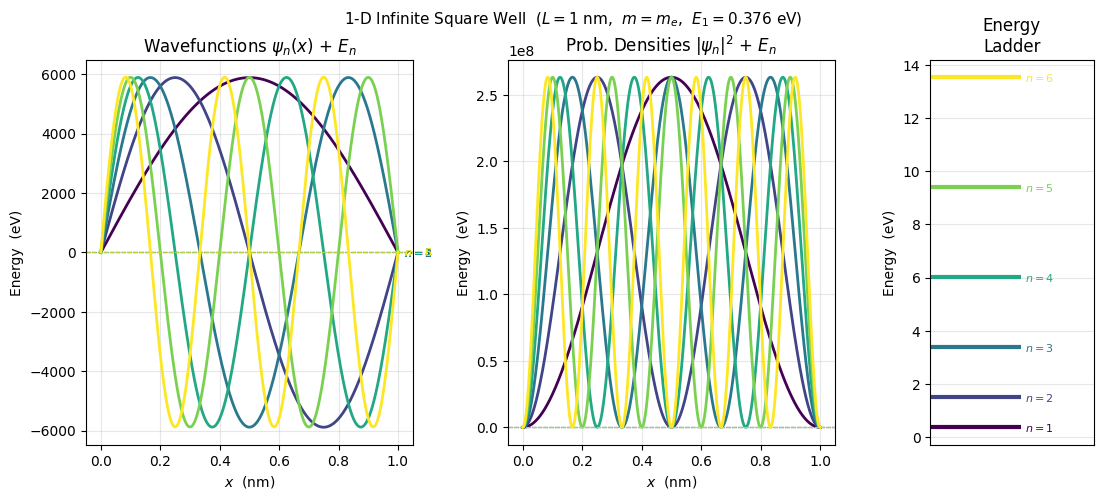

Ground-state energy E₁ = 0.3760 eV
Energy levels:  E1=0.376 eV  E2=1.504 eV  E3=3.384 eV  E4=6.016 eV  E5=9.401 eV  E6=13.537 eV


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# --- Physical constants ---
hbar = 1.0545718e-34   # J·s
m_e  = 9.10938e-31     # electron mass (kg)
eV   = 1.60218e-19     # 1 eV in joules

# --- Parameters ---
L    = 1e-9            # box width: 1 nm
m    = m_e             # electron
N_states = 6           # number of levels to show
x    = np.linspace(0, L, 1000)

# --- Analytic solutions ---
E1   = np.pi**2 * hbar**2 / (2 * m * L**2)   # ground-state energy (J)

def psi(n, x, L):
    """Normalised eigenfunction of the 1-D infinite square well."""
    return np.sqrt(2 / L) * np.sin(n * np.pi * x / L)

energies = np.array([n**2 * E1 for n in range(1, N_states + 1)])

# --- Figure ---
fig = plt.figure(figsize=(13, 5))
gs  = gridspec.GridSpec(1, 3, width_ratios=[2, 2, 1], wspace=0.35)

ax1 = fig.add_subplot(gs[0])
ax2 = fig.add_subplot(gs[1])
ax3 = fig.add_subplot(gs[2])

cmap = plt.cm.viridis
scale = 0.35 * E1 / eV   # visual amplitude of wavefunctions in eV units

for i, n in enumerate(range(1, N_states + 1)):
    color  = cmap(i / (N_states - 1))
    En_eV  = energies[i] / eV
    psi_n  = psi(n, x, L)

    # Wavefunctions (offset by energy level)
    ax1.plot(x * 1e9, psi_n * scale + En_eV, color=color, lw=2)
    ax1.axhline(En_eV, color=color, lw=0.8, ls="--", alpha=0.6)
    ax1.text(L * 1e9 * 1.02, En_eV, f"$n={n}$", va="center", fontsize=8, color=color)

    # Probability densities
    ax2.plot(x * 1e9, psi_n**2 * scale + En_eV, color=color, lw=2, label=f"$n={n}$")
    ax2.axhline(En_eV, color=color, lw=0.8, ls="--", alpha=0.6)

# Energy ladder
n_vals = np.arange(1, N_states + 1)
ax3.hlines(n_vals**2 * E1 / eV, 0, 1, colors=[cmap(i / (N_states - 1)) for i in range(N_states)], lw=3)
for i, n in enumerate(n_vals):
    ax3.text(1.05, n**2 * E1 / eV, f"$n={n}$", va="center", fontsize=8,
             color=cmap(i / (N_states - 1)))
ax3.set_xlim(0, 1.8)
ax3.set_ylabel("Energy  (eV)")
ax3.set_title("Energy\nLadder")
ax3.set_xticks([])
ax3.grid(True, axis="y", alpha=0.3)

ax1.set_xlabel("$x$  (nm)")
ax1.set_ylabel("Energy  (eV)")
ax1.set_title("Wavefunctions $\\psi_n(x)$ + $E_n$")
ax1.grid(True, alpha=0.3)

ax2.set_xlabel("$x$  (nm)")
ax2.set_ylabel("Energy  (eV)")
ax2.set_title("Prob. Densities $|\\psi_n|^2$ + $E_n$")
ax2.grid(True, alpha=0.3)

fig.suptitle(f"1-D Infinite Square Well  ($L = {L*1e9:.0f}$ nm,  $m = m_e$,"
             f"  $E_1 = {E1/eV:.3f}$ eV)", fontsize=11)
fig.tight_layout()
plt.show()

print(f"Ground-state energy E₁ = {E1/eV:.4f} eV")
print("Energy levels:  " + "  ".join([f"E{n}={n**2*E1/eV:.3f} eV" for n in range(1, N_states+1)]))

---
## 2. Particle in a 2-D Infinite Square Well

For a particle in a rectangular box of sides $L_x \times L_y$ the Hamiltonian
separates and the exact eigenfunctions are products of 1-D solutions:

$$\psi_{n_x,n_y}(x,y) = \frac{2}{\sqrt{L_x L_y}}
  \sin\!\left(\frac{n_x\pi x}{L_x}\right)
  \sin\!\left(\frac{n_y\pi y}{L_y}\right)$$

$$E_{n_x,n_y} = \frac{\pi^2\hbar^2}{2m}
  \left(\frac{n_x^2}{L_x^2} + \frac{n_y^2}{L_y^2}\right)$$

For a **square** box ($L_x = L_y = L$) states with the same value of
$n_x^2 + n_y^2$ are degenerate. We plot the probability densities of the
first nine distinct energy levels and mark degenerate pairs.

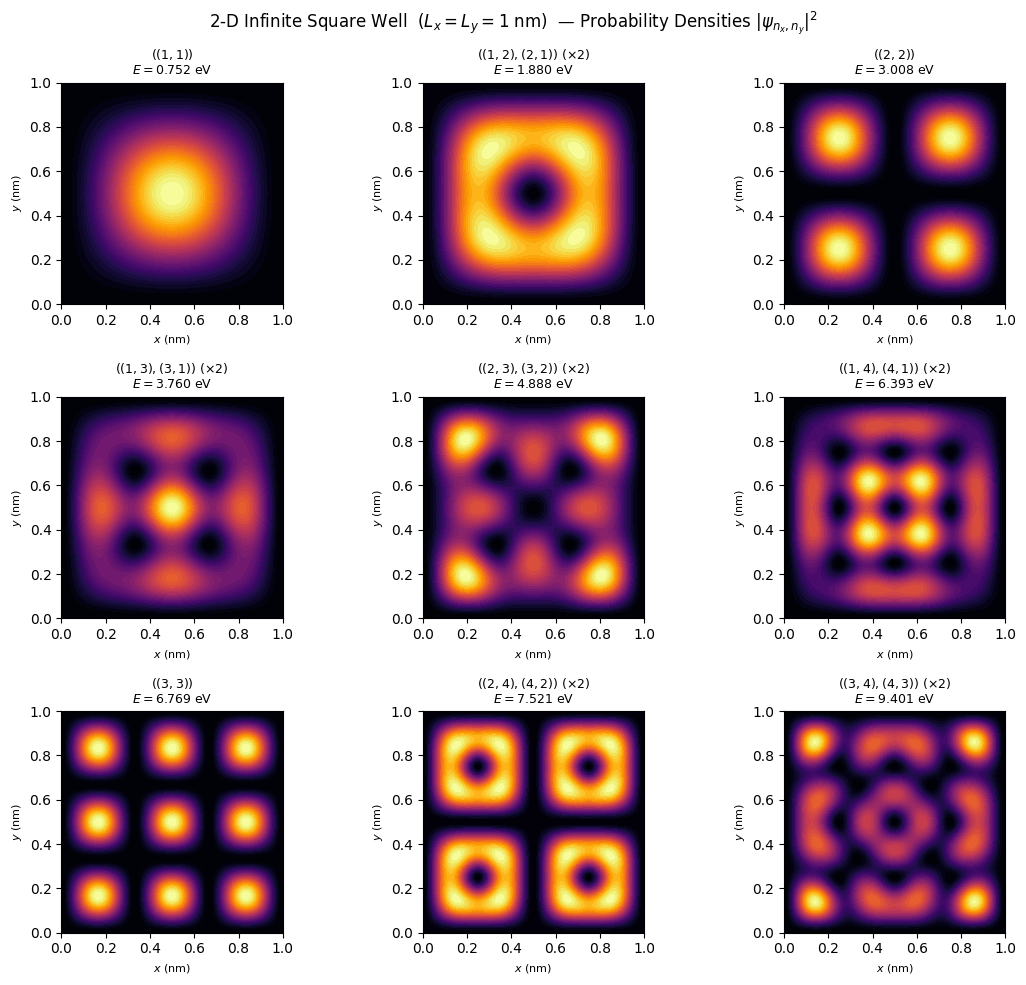

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# --- Parameters ---
Lx, Ly = 1e-9, 1e-9      # square box, 1 nm × 1 nm
Nx, Ny = 300, 300
x2 = np.linspace(0, Lx, Nx)
y2 = np.linspace(0, Ly, Ny)
X, Y = np.meshgrid(x2, y2)

hbar = 1.0545718e-34
m_e  = 9.10938e-31
eV   = 1.60218e-19
E1_2D = np.pi**2 * hbar**2 / (2 * m_e * Lx**2)

def psi2d(nx, ny, X, Y, Lx, Ly):
    """Normalised eigenfunction of the 2-D infinite square well."""
    return (2 / np.sqrt(Lx * Ly) * np.sin(nx * np.pi * X / Lx)
                                  * np.sin(ny * np.pi * Y / Ly))

def energy2d(nx, ny, Lx, Ly):
    return np.pi**2 * hbar**2 / (2 * m_e) * (nx**2 / Lx**2 + ny**2 / Ly**2)

# Build and sort the first 9 (nx, ny) levels by energy
quantum_numbers = [(nx, ny) for nx in range(1, 6) for ny in range(1, 6)]
quantum_numbers.sort(key=lambda q: q[0]**2 + q[1]**2)

# Group by degeneracy (same nx²+ny²)
seen = {}
for nx, ny in quantum_numbers:
    key = nx**2 + ny**2
    seen.setdefault(key, []).append((nx, ny))
groups = list(seen.values())[:9]

fig2d, axes2d = plt.subplots(3, 3, figsize=(11, 10))
for ax, group in zip(axes2d.flat, groups):
    nx, ny = group[0]
    En = energy2d(nx, ny, Lx, Ly)
    prob = sum(psi2d(nxi, nyi, X, Y, Lx, Ly)**2 for nxi, nyi in group)
    ax.contourf(X * 1e9, Y * 1e9, prob, levels=40, cmap="inferno")
    deg_label = f" (×{len(group)})" if len(group) > 1 else ""
    states_str = ", ".join([f"({nxi},{nyi})" for nxi, nyi in group])
    ax.set_title(f"$({states_str})${deg_label}\n$E = {En/eV:.3f}$ eV", fontsize=9)
    ax.set_xlabel("$x$ (nm)", fontsize=8)
    ax.set_ylabel("$y$ (nm)", fontsize=8)
    ax.set_aspect("equal")

fig2d.suptitle(f"2-D Infinite Square Well  ($L_x = L_y = {Lx*1e9:.0f}$ nm)  "
               f"— Probability Densities $|\\psi_{{n_x,n_y}}|^2$", fontsize=12)
fig2d.tight_layout()
plt.show()

---
## 3. Quantum Harmonic Oscillator

The potential $V(x) = \frac{1}{2}m\omega^2 x^2$ gives equally spaced energy
levels and Hermite-polynomial eigenfunctions:

$$E_n = \hbar\omega\left(n + \tfrac{1}{2}\right), \qquad
  \psi_n(x) = \left(\frac{m\omega}{\pi\hbar}\right)^{1/4}
  \frac{1}{\sqrt{2^n n!}}\,
  H_n\!\left(\sqrt{\frac{m\omega}{\hbar}}\,x\right)
  e^{-m\omega x^2/(2\hbar)}$$

We display wavefunctions, probability densities, and the classical turning
points $x_{\pm} = \pm\sqrt{2E_n/(m\omega^2)}$.  We also verify the
Heisenberg uncertainty principle $\sigma_x\,\sigma_p \ge \hbar/2$.

Heisenberg uncertainty  σ_x · σ_p / (ℏ/2)  for each level:
  n=0:  σ_x·σ_p / (ℏ/2) = 1.0000  (minimum uncertainty for n=0)
  n=1:  σ_x·σ_p / (ℏ/2) = 3.0000  (minimum uncertainty for n=0)
  n=2:  σ_x·σ_p / (ℏ/2) = 5.0000  (minimum uncertainty for n=0)
  n=3:  σ_x·σ_p / (ℏ/2) = 7.0000  (minimum uncertainty for n=0)
  n=4:  σ_x·σ_p / (ℏ/2) = 9.0000  (minimum uncertainty for n=0)
  n=5:  σ_x·σ_p / (ℏ/2) = 11.0000  (minimum uncertainty for n=0)


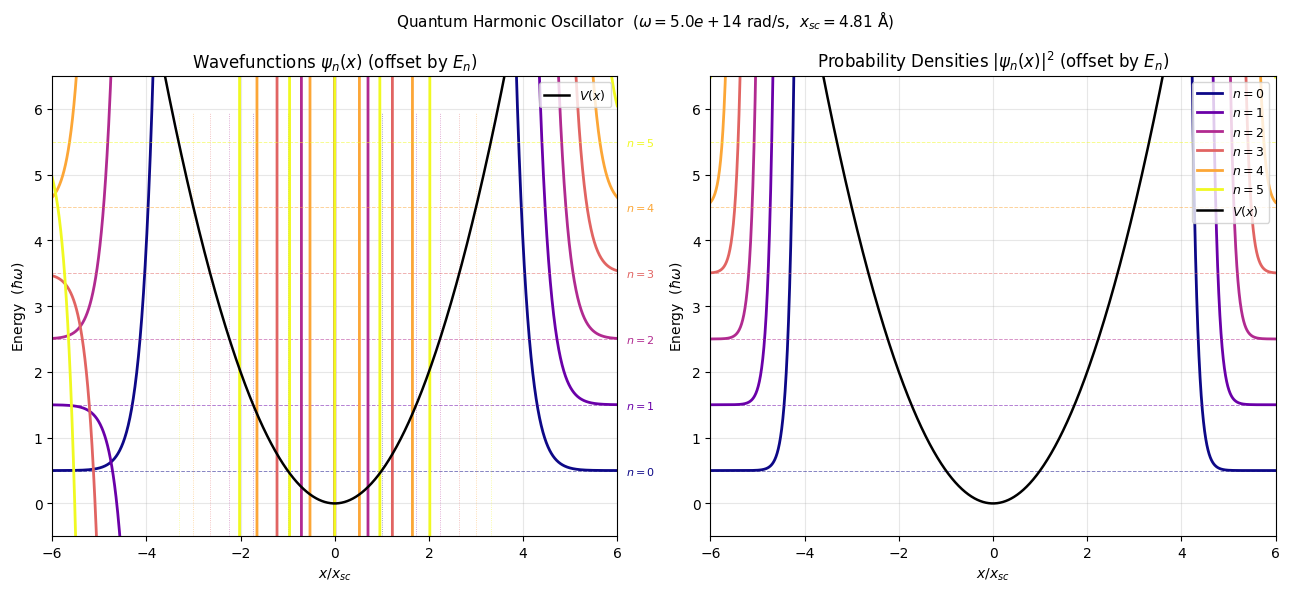

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import hermite, factorial

# --- Parameters ---
hbar = 1.0545718e-34
m_e  = 9.10938e-31
eV   = 1.60218e-19
omega = 5e14             # angular frequency (rad/s) — infrared regime
m     = m_e
x_sc  = np.sqrt(hbar / (m * omega))   # characteristic length

N_qho   = 6
x_range = 6 * x_sc
x_qho   = np.linspace(-x_range, x_range, 2000)

def psi_qho(n, x):
    """Normalised QHO eigenfunction using scipy's probabilist Hermite polynomials."""
    Hn     = hermite(n)
    norm   = (m * omega / (np.pi * hbar))**0.25 / np.sqrt(2**n * factorial(n))
    xi     = np.sqrt(m * omega / hbar) * x
    return norm * Hn(xi) * np.exp(-0.5 * xi**2)

energies_qho = np.array([(n + 0.5) * hbar * omega for n in range(N_qho)])
V_qho = 0.5 * m * omega**2 * x_qho**2

fig, axes = plt.subplots(1, 2, figsize=(13, 6))
cmap = plt.cm.plasma
scale_qho = 0.3 * hbar * omega

for i, n in enumerate(range(N_qho)):
    color = cmap(i / (N_qho - 1))
    En    = energies_qho[i]
    psi_n = psi_qho(n, x_qho)

    # Classical turning points
    x_turn = np.sqrt(2 * En / (m * omega**2))

    # --- Left panel: wavefunctions ---
    axes[0].plot(x_qho / x_sc, psi_n * scale_qho / (hbar * omega) + En / (hbar * omega),
                 color=color, lw=2)
    axes[0].axhline(En / (hbar * omega), color=color, lw=0.7, ls="--", alpha=0.5)
    axes[0].axvline( x_turn / x_sc, ymin=0, ymax=0.92, color=color, lw=0.6, ls=":", alpha=0.5)
    axes[0].axvline(-x_turn / x_sc, ymin=0, ymax=0.92, color=color, lw=0.6, ls=":", alpha=0.5)
    axes[0].text(x_range / x_sc * 1.03, En / (hbar * omega), f"$n={n}$",
                 va="center", fontsize=8, color=color)

    # --- Right panel: probability densities ---
    axes[1].plot(x_qho / x_sc, psi_n**2 * scale_qho / (hbar * omega) + En / (hbar * omega),
                 color=color, lw=2, label=f"$n={n}$")
    axes[1].axhline(En / (hbar * omega), color=color, lw=0.7, ls="--", alpha=0.5)

# Potential
axes[0].plot(x_qho / x_sc, V_qho / (hbar * omega), "k-", lw=1.8, label="$V(x)$")
axes[1].plot(x_qho / x_sc, V_qho / (hbar * omega), "k-", lw=1.8, label="$V(x)$")

for ax in axes:
    ax.set_xlim(-x_range / x_sc, x_range / x_sc)
    ax.set_ylim(-0.5, N_qho + 0.5)
    ax.set_xlabel(r"$x / x_{sc}$")
    ax.set_ylabel(r"Energy  $(\hbar\omega)$")
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=9, loc="upper right")

axes[0].set_title("Wavefunctions $\\psi_n(x)$ (offset by $E_n$)")
axes[1].set_title("Probability Densities $|\\psi_n(x)|^2$ (offset by $E_n$)")

# Uncertainty principle check
print("Heisenberg uncertainty  σ_x · σ_p / (ℏ/2)  for each level:")
for n in range(N_qho):
    sigma_x = np.sqrt((n + 0.5) * hbar / (m * omega))    # exact for QHO
    sigma_p = np.sqrt((n + 0.5) * m * hbar * omega)
    ratio   = sigma_x * sigma_p / (hbar / 2)
    print(f"  n={n}:  σ_x·σ_p / (ℏ/2) = {ratio:.4f}  (minimum uncertainty for n=0)")

fig.suptitle(f"Quantum Harmonic Oscillator  "
             f"($\\omega = {omega:.1e}$ rad/s,  "
             f"$x_{{sc}} = {x_sc*1e10:.2f}$ Å)", fontsize=11)
fig.tight_layout()
plt.show()

---
## 4. Lennard-Jones Potential — Bound States via the Numerov Method

The Lennard-Jones (12-6) potential between two neutral atoms is:

$$V(r) = 4\varepsilon\left[\left(\frac{\sigma}{r}\right)^{12}
         - \left(\frac{\sigma}{r}\right)^{6}\right]$$

with a minimum at $r_0 = 2^{1/6}\sigma$ of depth $-\varepsilon$.
For the 1-D radial Schrödinger equation we solve numerically using the
**Numerov algorithm**, which is second-order and exact for equations of the
form $\psi'' = f(x)\psi$:

$$\psi_{i+1} = \frac{2\psi_i(1 - \frac{5h^2}{12}f_i) - \psi_{i-1}(1 + \frac{h^2}{12}f_{i-1})}
              {1 + \frac{h^2}{12}f_{i+1}}$$

Bound states are found by shooting from both ends and matching in the
classical turning region (Numerov shooting method).

Found 42 bound state(s):
  n=0:  E = -10.1083 meV  (-0.9720 ε)
  n=1:  E = -9.7119 meV  (-0.9338 ε)
  n=2:  E = -9.3164 meV  (-0.8958 ε)
  n=3:  E = -8.9239 meV  (-0.8581 ε)
  n=4:  E = -8.5359 meV  (-0.8208 ε)
  n=5:  E = -8.1546 meV  (-0.7841 ε)
  n=6:  E = -8.1126 meV  (-0.7801 ε)
  n=7:  E = -7.7759 meV  (-0.7477 ε)
  n=8:  E = -7.4055 meV  (-0.7121 ε)
  n=9:  E = -7.0418 meV  (-0.6771 ε)
  n=10:  E = -6.6851 meV  (-0.6428 ε)
  n=11:  E = -6.3357 meV  (-0.6092 ε)
  n=12:  E = -5.9937 meV  (-0.5763 ε)
  n=13:  E = -5.6594 meV  (-0.5442 ε)
  n=14:  E = -5.3329 meV  (-0.5128 ε)
  n=15:  E = -5.0144 meV  (-0.4822 ε)
  n=16:  E = -4.7039 meV  (-0.4523 ε)
  n=17:  E = -4.4017 meV  (-0.4232 ε)
  n=18:  E = -4.1079 meV  (-0.3950 ε)
  n=19:  E = -3.8225 meV  (-0.3676 ε)
  n=20:  E = -3.5458 meV  (-0.3409 ε)
  n=21:  E = -3.2778 meV  (-0.3152 ε)
  n=22:  E = -3.0187 meV  (-0.2903 ε)
  n=23:  E = -2.7685 meV  (-0.2662 ε)
  n=24:  E = -2.5275 meV  (-0.2430 ε)
  n=25:  E = -2.2957 meV  (-0.2207

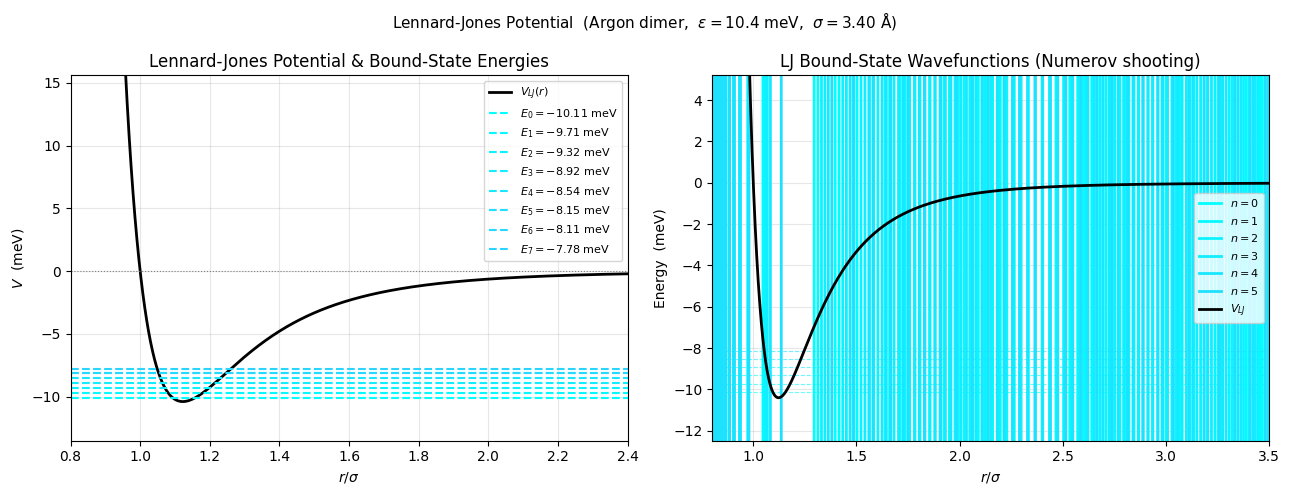

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import brentq

# --- LJ parameters (Argon dimer) ---
eps_LJ  = 0.0104 * 1.60218e-19     # well depth (J);  0.0104 eV for Ar–Ar
sigma_LJ = 3.40e-10                 # collision diameter (m)
m_Ar    = 39.948 * 1.66054e-27      # Ar reduced mass (kg)
hbar    = 1.0545718e-34
eV      = 1.60218e-19

r0_LJ   = 2**(1/6) * sigma_LJ      # equilibrium separation

def V_LJ(r):
    sr6 = (sigma_LJ / r)**6
    return 4 * eps_LJ * (sr6**2 - sr6)

# --- Numerov solver ---
def numerov_shoot(E, r_arr, V_arr, m, hbar):
    """
    Integrate ψ from left boundary inward. Returns the wavefunction array.
    Schrödinger: ψ'' = -(2m/ℏ²)(E - V)ψ  =>  f(r) = -2m(E-V)/ℏ²
    """
    h  = r_arr[1] - r_arr[0]
    f  = 2 * m * (V_arr - E) / hbar**2
    psi = np.zeros(len(r_arr))
    psi[0] = 0.0
    psi[1] = 1e-8                   # small initial slope
    for i in range(1, len(r_arr) - 1):
        num = 2 * psi[i] * (1 - 5/12 * h**2 * f[i]) - psi[i-1] * (1 + h**2/12 * f[i-1])
        den = 1 + h**2 / 12 * f[i+1]
        psi[i+1] = num / den
        if np.abs(psi[i+1]) > 1e30:     # overflow guard
            break
    return psi

def match_value(E, r_arr, V_arr, m, hbar):
    """Return ψ at the right boundary (should vanish for bound states)."""
    psi = numerov_shoot(E, r_arr, V_arr, m, hbar)
    return psi[-1]

# --- Grid ---
r_min = 0.8 * sigma_LJ
r_max = 4.0 * sigma_LJ
Nr    = 3000
r_arr = np.linspace(r_min, r_max, Nr)
V_arr = V_LJ(r_arr)

# --- Energy scan to find sign changes (bound states below 0) ---
E_scan = np.linspace(-eps_LJ * 0.999, -eps_LJ * 0.001, 2000)
vals   = [match_value(E, r_arr, V_arr, m_Ar, hbar) for E in E_scan]
vals   = np.array(vals)

bound_energies = []
for i in range(len(vals) - 1):
    if np.sign(vals[i]) != np.sign(vals[i + 1]) and np.isfinite(vals[i]) and np.isfinite(vals[i+1]):
        try:
            E_bs = brentq(match_value, E_scan[i], E_scan[i+1],
                          args=(r_arr, V_arr, m_Ar, hbar), xtol=1e-30)
            bound_energies.append(E_bs)
        except ValueError:
            pass

print(f"Found {len(bound_energies)} bound state(s):")
for k, E in enumerate(bound_energies):
    print(f"  n={k}:  E = {E/eV*1000:.4f} meV  ({E/eps_LJ:.4f} ε)")

# --- Plot ---
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

r_plot = np.linspace(r_min * 1.0, r_max * 0.9, 1000)
axes[0].plot(r_plot / sigma_LJ, V_LJ(r_plot) / eV * 1000, "k-", lw=2, label="$V_{LJ}(r)$")
axes[0].axhline(0, color="gray", lw=0.8, ls=":")

cmap_lj = plt.cm.cool
for k, E in enumerate(bound_energies[:8]):
    color  = cmap_lj(k / max(len(bound_energies) - 1, 1))
    axes[0].axhline(E / eV * 1000, color=color, lw=1.5, ls="--",
                    label=f"$E_{k} = {E/eV*1000:.2f}$ meV")

axes[0].set_xlabel("$r / \\sigma$")
axes[0].set_ylabel("$V$  (meV)")
axes[0].set_ylim(-eps_LJ / eV * 1000 * 1.3, eps_LJ / eV * 1000 * 1.5)
axes[0].set_xlim(r_min / sigma_LJ, r_max * 0.6 / sigma_LJ)
axes[0].set_title("Lennard-Jones Potential & Bound-State Energies")
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3)

# Wavefunctions panel
scale_lj = eps_LJ / eV * 1000 * 0.35
for k, E in enumerate(bound_energies[:6]):
    color = cmap_lj(k / max(len(bound_energies) - 1, 1))
    psi   = numerov_shoot(E, r_arr, V_arr, m_Ar, hbar)
    # normalise
    psi  /= np.sqrt(np.trapezoid(psi**2, r_arr))
    axes[1].plot(r_arr / sigma_LJ, psi * scale_lj + E / eV * 1000,
                 color=color, lw=2, label=f"$n={k}$")
    axes[1].axhline(E / eV * 1000, color=color, lw=0.8, ls="--", alpha=0.6)

axes[1].plot(r_arr / sigma_LJ, V_LJ(r_arr) / eV * 1000, "k-", lw=2, label="$V_{LJ}$")
axes[1].set_xlabel("$r / \\sigma$")
axes[1].set_ylabel("Energy  (meV)")
axes[1].set_ylim(-eps_LJ / eV * 1000 * 1.2, eps_LJ / eV * 1000 * 0.5)
axes[1].set_xlim(r_min / sigma_LJ, 3.5)
axes[1].set_title("LJ Bound-State Wavefunctions (Numerov shooting)")
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.3)

fig.suptitle(f"Lennard-Jones Potential  (Argon dimer,  "
             f"$\\varepsilon = {eps_LJ/eV*1000:.1f}$ meV,  "
             f"$\\sigma = {sigma_LJ*1e10:.2f}$ Å)", fontsize=11)
fig.tight_layout()
plt.show()

---
## 5. Kronig–Penney Model — Electronic Band Structure

The **Kronig–Penney model** describes an electron in a 1-D periodic crystal
as a sequence of rectangular potential barriers of height $V_0$, width $b$,
and period $a + b$.  Bloch's theorem requires:

$$\cos(k_{\rm Bloch}(a+b)) = \cos(\alpha a)\cos(\beta b)
  - \frac{\alpha^2+\beta^2}{2\alpha\beta}\sin(\alpha a)\sin(\beta b)$$

where $\alpha = \sqrt{2mE}/\hbar$ and $\beta = \sqrt{2m(V_0 - E)}/\hbar$
(for $E < V_0$).  Solutions exist only where the right-hand side lies in
$[-1,\,1]$ — these are the **allowed bands**.  The rest are **band gaps**.

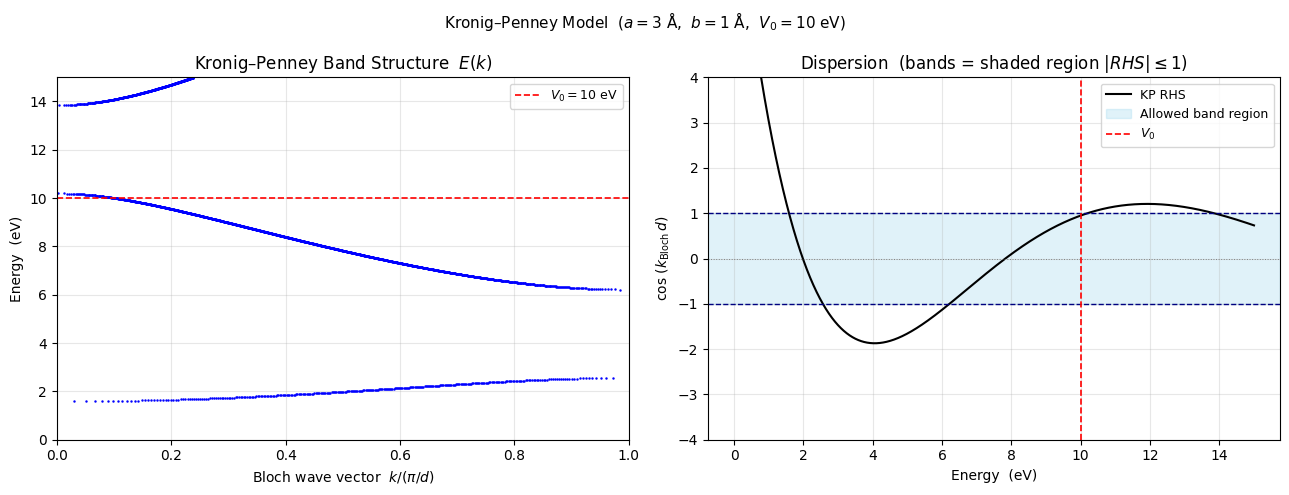

In [5]:
import numpy as np
import matplotlib.pyplot as plt

# --- Parameters ---
hbar = 1.0545718e-34
m_e  = 9.10938e-31
eV   = 1.60218e-19

a_kp   = 3e-10          # well width  (m) — atom spacing
b_kp   = 1e-10          # barrier width (m)
V0_kp  = 10.0 * eV      # barrier height (J)
period = a_kp + b_kp    # lattice constant

N_E  = 5000
E_kp = np.linspace(0.001 * eV, 1.5 * V0_kp, N_E)

def KP_rhs(E, a, b, V0, m, hbar):
    """Right-hand side of the Kronig–Penney dispersion relation."""
    alpha = np.sqrt(2 * m * np.abs(E)) / hbar
    rhs   = np.zeros_like(E, dtype=float)

    for i, Ei in enumerate(E):
        if Ei < 0:
            rhs[i] = np.nan
        elif Ei < V0:
            beta = np.sqrt(2 * m * (V0 - Ei)) / hbar
            rhs[i] = (np.cos(alpha[i] * a) * np.cosh(beta * b)
                      - (alpha[i]**2 - beta**2) / (2 * alpha[i] * beta)
                      * np.sin(alpha[i] * a) * np.sinh(beta * b))
        else:
            beta = np.sqrt(2 * m * (Ei - V0)) / hbar
            rhs[i] = (np.cos(alpha[i] * a) * np.cos(beta * b)
                      - (alpha[i]**2 + beta**2) / (2 * alpha[i] * beta)
                      * np.sin(alpha[i] * a) * np.sin(beta * b))
    return rhs

alpha_arr = np.sqrt(2 * m_e * np.abs(E_kp)) / hbar
rhs_arr   = KP_rhs(E_kp, a_kp, b_kp, V0_kp, m_e, hbar)

# Allowed when |rhs| <= 1
allowed = np.abs(rhs_arr) <= 1.0

# Bloch wave vector k from cos(k·d) = rhs
k_bloch = np.full(N_E, np.nan)
k_bloch[allowed] = np.arccos(np.clip(rhs_arr[allowed], -1, 1)) / period

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# --- Left: E(k) band structure ---
ax = axes[0]
ax.plot(k_bloch / (np.pi / period), E_kp / eV, "b.", ms=1.5, rasterized=True)
ax.set_xlabel("Bloch wave vector  $k / (\\pi/d)$")
ax.set_ylabel("Energy  (eV)")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1.5 * V0_kp / eV)
ax.axhline(V0_kp / eV, color="red", lw=1.2, ls="--", label=f"$V_0 = {V0_kp/eV:.0f}$ eV")
ax.set_title("Kronig–Penney Band Structure  $E(k)$")
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# --- Right: RHS vs E — band/gap visualisation ---
ax2 = axes[1]
ax2.plot(E_kp / eV, rhs_arr, "k-", lw=1.5, label="KP RHS")
ax2.axhspan(-1, 1, color="skyblue", alpha=0.25, label="Allowed band region")
ax2.axhline( 1, color="navy", lw=1, ls="--")
ax2.axhline(-1, color="navy", lw=1, ls="--")
ax2.axhline( 0, color="gray", lw=0.7, ls=":")
ax2.axvline(V0_kp / eV, color="red", lw=1.2, ls="--", label=f"$V_0$")
ax2.set_xlabel("Energy  (eV)")
ax2.set_ylabel(r"$\cos\,(k_{\rm Bloch}\,d)$")
ax2.set_ylim(-4, 4)
ax2.set_title(f"Dispersion  (bands = shaded region "
              f"$|RHS| \\leq 1$)")
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3)

fig.suptitle(f"Kronig–Penney Model  ($a = {a_kp*1e10:.0f}$ Å,  "
             f"$b = {b_kp*1e10:.0f}$ Å,  $V_0 = {V0_kp/eV:.0f}$ eV)", fontsize=11)
fig.tight_layout()
plt.show()

---
## 6. Hydrogen Atom — Radial Wavefunctions & Probability Densities

For hydrogen the radial part of the Schrödinger equation gives:

$$R_{nl}(r) = -\sqrt{\left(\frac{2}{na_0}\right)^3\frac{(n-l-1)!}{2n[(n+l)!]^3}}
  e^{-r/(na_0)}\left(\frac{2r}{na_0}\right)^l
  L_{n-l-1}^{2l+1}\!\left(\frac{2r}{na_0}\right)$$

with Bohr radius $a_0 = 0.529177$ Å and energy levels
$E_n = -13.6\,\text{eV}/n^2$.
The **radial probability density** is $P(r) = r^2|R_{nl}(r)|^2$.
The most probable radius for $1s$ is exactly $a_0$.

Hydrogen energy levels:
  n=1:  E = -13.6057 eV   (most probable r for 1s-like: 1 a₀)
  n=2:  E = -3.4014 eV   (most probable r for 1s-like: 4 a₀)
  n=3:  E = -1.5117 eV   (most probable r for 1s-like: 9 a₀)
  n=4:  E = -0.8504 eV   (most probable r for 1s-like: 16 a₀)


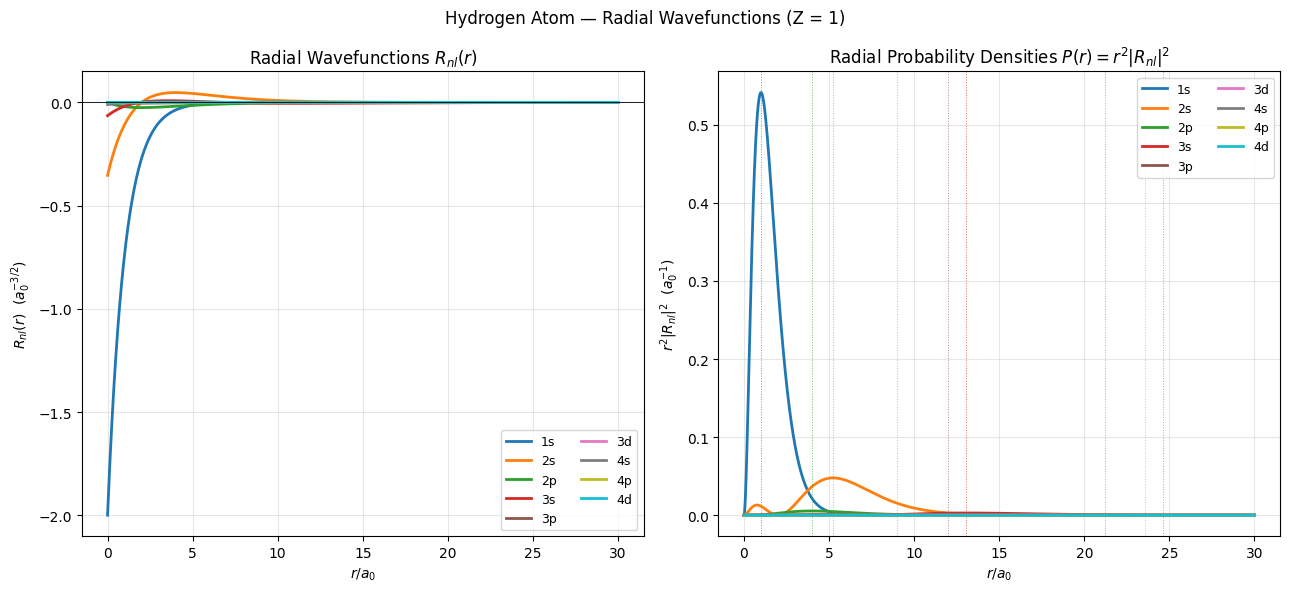

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import genlaguerre, factorial

# --- Constants ---
a0   = 5.29177e-11      # Bohr radius (m)
eV   = 1.60218e-19
E_H  = -13.6057         # eV — hydrogen ground state

def R_nl(n, l, r):
    """
    Hydrogen radial wavefunction R_{nl}(r).
    Uses the associated Laguerre polynomial L_{n-l-1}^{2l+1}.
    """
    rho  = 2 * r / (n * a0)
    norm = -np.sqrt((2 / (n * a0))**3 *
                    factorial(n - l - 1) / (2 * n * factorial(n + l)**3))
    L    = genlaguerre(n - l - 1, 2 * l + 1)
    return norm * np.exp(-rho / 2) * rho**l * L(rho)

# States to display: (n, l, label)
states = [
    (1, 0, "1s"), (2, 0, "2s"), (2, 1, "2p"),
    (3, 0, "3s"), (3, 1, "3p"), (3, 2, "3d"),
    (4, 0, "4s"), (4, 1, "4p"), (4, 2, "4d"),
]

r_max_plot = 30 * a0
r_H  = np.linspace(1e-14, r_max_plot, 4000)

fig, axes = plt.subplots(1, 2, figsize=(13, 6))
cmap_H = plt.cm.tab10

for i, (n, l, lbl) in enumerate(states):
    color  = cmap_H(i / (len(states) - 1))
    R      = R_nl(n, l, r_H)
    P      = r_H**2 * R**2    # radial probability density

    # Most probable radius (analytical: a0 * n^2 / Z for 1s-like)
    idx_peak = np.argmax(P)

    axes[0].plot(r_H / a0, R / (1 / a0)**1.5, color=color, lw=2, label=lbl)
    axes[1].plot(r_H / a0, P * a0, color=color, lw=2, label=lbl)
    axes[1].axvline(r_H[idx_peak] / a0, color=color, lw=0.7, ls=":", alpha=0.7)

axes[0].axhline(0, color="k", lw=0.6)
axes[0].set_xlabel("$r / a_0$")
axes[0].set_ylabel("$R_{nl}(r)$  ($a_0^{-3/2}$)")
axes[0].set_title("Radial Wavefunctions $R_{nl}(r)$")
axes[0].legend(fontsize=9, ncol=2)
axes[0].grid(True, alpha=0.3)

axes[1].set_xlabel("$r / a_0$")
axes[1].set_ylabel("$r^2|R_{nl}|^2$  ($a_0^{-1}$)")
axes[1].set_title("Radial Probability Densities $P(r) = r^2|R_{nl}|^2$")
axes[1].legend(fontsize=9, ncol=2)
axes[1].grid(True, alpha=0.3)

# Energy level table
print("Hydrogen energy levels:")
for n in range(1, 5):
    print(f"  n={n}:  E = {E_H / n**2:.4f} eV   "
          f"(most probable r for 1s-like: {n**2:.0f} a₀)")

fig.suptitle("Hydrogen Atom — Radial Wavefunctions (Z = 1)", fontsize=12)
fig.tight_layout()
plt.show()

---
## 7. Finite Square Well — Bound-State Transcendental Equation

For a symmetric finite well of depth $V_0$ and half-width $a$, the
Schrödinger equation is solved by matching even (cosine) and odd (sine)
interior solutions to exterior decaying exponentials.  Bound states occur
at discrete energies satisfying the **transcendental equations**:

**Even parity:**  $\kappa = k\tan(ka)$

**Odd parity:**   $\kappa = -k\cot(ka)$

where $k = \sqrt{2mE}/\hbar$ (inside) and $\kappa = \sqrt{2m(V_0-E)}/\hbar$
(outside).  Setting $z = ka$ and $z_0 = a\sqrt{2mV_0}/\hbar$, the equations
become $\sqrt{z_0^2 - z^2} = z\tan z$ (even) and $= -z\cot z$ (odd).

z₀ = 7.245  (determines number of bound states)

Found 9 bound state(s):
  n=0 (even):  z = 1.3793,  E = 1.8120 eV  (binding = 48.1880 eV)
  n=1 (even):  z = 1.5708,  E = 2.3502 eV  (binding = 47.6498 eV)
  n=2 (odd):  z = 2.7520,  E = 7.2136 eV  (binding = 42.7864 eV)
  n=3 (odd):  z = 3.1416,  E = 9.4007 eV  (binding = 40.5993 eV)
  n=4 (even):  z = 4.1093,  E = 16.0843 eV  (binding = 33.9157 eV)
  n=5 (even):  z = 4.7124,  E = 21.1517 eV  (binding = 28.8483 eV)
  n=6 (odd):  z = 5.4349,  E = 28.1351 eV  (binding = 21.8649 eV)
  n=7 (odd):  z = 6.2832,  E = 37.6030 eV  (binding = 12.3970 eV)
  n=8 (even):  z = 6.6806,  E = 42.5102 eV  (binding = 7.4898 eV)


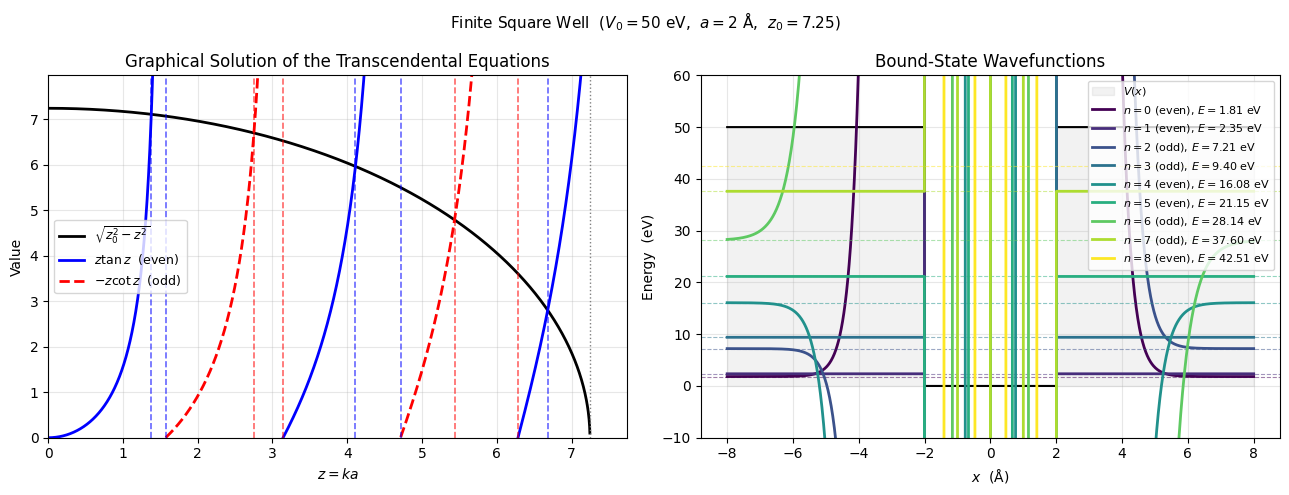

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import brentq

# --- Parameters ---
hbar = 1.0545718e-34
m_e  = 9.10938e-31
eV   = 1.60218e-19
V0_fsw = 50.0 * eV     # well depth
a_fsw  = 2.0e-10       # half-width (2 Å)

z0 = a_fsw * np.sqrt(2 * m_e * V0_fsw) / hbar   # characteristic parameter
print(f"z₀ = {z0:.3f}  (determines number of bound states)")

z_arr = np.linspace(0.001, z0 * 0.9999, 2000)

# Graphical solution
lhs     = np.sqrt(np.maximum(z0**2 - z_arr**2, 0))
rhs_even = z_arr * np.tan(z_arr)
rhs_odd  = -z_arr / np.tan(z_arr)

# Find bound states numerically
def even_eq(z): return z * np.tan(z) - np.sqrt(max(z0**2 - z**2, 0))
def odd_eq(z):  return -z / np.tan(z) - np.sqrt(max(z0**2 - z**2, 0))

bound_states = []
for start, end in zip(z_arr[:-1], z_arr[1:]):
    for eq, parity in [(even_eq, "even"), (odd_eq, "odd")]:
        try:
            if np.sign(eq(start)) != np.sign(eq(end)):
                z_sol = brentq(eq, start, end, xtol=1e-10)
                E_sol = (hbar * z_sol / a_fsw)**2 / (2 * m_e)
                bound_states.append((z_sol, E_sol, parity))
        except Exception:
            pass

bound_states.sort(key=lambda s: s[1])
print(f"\nFound {len(bound_states)} bound state(s):")
for k, (z_sol, E_sol, par) in enumerate(bound_states):
    print(f"  n={k} ({par}):  z = {z_sol:.4f},  E = {E_sol/eV:.4f} eV  "
          f"(binding = {(V0_fsw - E_sol)/eV:.4f} eV)")

# --- Graphical solution plot ---
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
ax.plot(z_arr, lhs,      "k-",  lw=2,   label="$\\sqrt{z_0^2 - z^2}$")
ax.plot(z_arr, np.where(rhs_even > 0, rhs_even, np.nan), "b-",  lw=2, label="$z\\tan z$  (even)")
ax.plot(z_arr, np.where(rhs_odd  > 0, rhs_odd,  np.nan), "r--", lw=2, label="$-z\\cot z$  (odd)")
ax.axvline(z0, color="gray", ls=":", lw=1)

for z_sol, _, par in bound_states:
    color = "blue" if par == "even" else "red"
    ax.axvline(z_sol, color=color, lw=1.2, ls="--", alpha=0.6)

ax.set_xlim(0, z0 + 0.5)
ax.set_ylim(0, z0 * 1.1)
ax.set_xlabel("$z = ka$")
ax.set_ylabel("Value")
ax.set_title("Graphical Solution of the Transcendental Equations")
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# --- Wavefunction plot ---
ax2  = axes[1]
x_fsw = np.linspace(-4 * a_fsw, 4 * a_fsw, 2000)
V_plot = np.where(np.abs(x_fsw) <= a_fsw, 0.0, V0_fsw)
ax2.fill_between(x_fsw * 1e10, V_plot / eV, alpha=0.1, color="gray", label="$V(x)$")
ax2.plot(x_fsw * 1e10, V_plot / eV, "k-", lw=1.5)

scale_fsw = V0_fsw / eV * 0.12
cmap_fsw  = plt.cm.viridis
for k, (z_sol, E_sol, par) in enumerate(bound_states):
    color = cmap_fsw(k / max(len(bound_states) - 1, 1))
    k_in  = z_sol / a_fsw
    kap   = np.sqrt(2 * m_e * (V0_fsw - E_sol)) / hbar

    psi_fsw = np.zeros_like(x_fsw)
    inside  = np.abs(x_fsw) <= a_fsw
    outside = ~inside

    if par == "even":
        A = 1.0
        B = np.cos(k_in * a_fsw) * np.exp(kap * a_fsw)
        psi_fsw[inside]              = A * np.cos(k_in * x_fsw[inside])
        psi_fsw[x_fsw >  a_fsw]  =  B * np.exp(-kap * x_fsw[x_fsw >  a_fsw])
        psi_fsw[x_fsw < -a_fsw]  =  B * np.exp( kap * x_fsw[x_fsw < -a_fsw])
    else:
        A = 1.0
        B = np.sin(k_in * a_fsw) * np.exp(kap * a_fsw)
        psi_fsw[inside]              = A * np.sin(k_in * x_fsw[inside])
        psi_fsw[x_fsw >  a_fsw]  =  B * np.exp(-kap * x_fsw[x_fsw >  a_fsw])
        psi_fsw[x_fsw < -a_fsw]  = -B * np.exp( kap * x_fsw[x_fsw < -a_fsw])

    norm = np.sqrt(np.trapezoid(psi_fsw**2, x_fsw))
    psi_fsw /= norm
    ax2.plot(x_fsw * 1e10, psi_fsw * scale_fsw + E_sol / eV,
             color=color, lw=2, label=f"$n={k}$ ({par}), $E={E_sol/eV:.2f}$ eV")
    ax2.axhline(E_sol / eV, color=color, lw=0.8, ls="--", alpha=0.5)

ax2.set_xlabel("$x$  (Å)")
ax2.set_ylabel("Energy  (eV)")
ax2.set_title("Bound-State Wavefunctions")
ax2.set_ylim(-V0_fsw / eV * 0.2, V0_fsw / eV * 1.2)
ax2.legend(fontsize=8, loc="upper right")
ax2.grid(True, alpha=0.3)

fig.suptitle(f"Finite Square Well  ($V_0 = {V0_fsw/eV:.0f}$ eV,  $a = {a_fsw*1e10:.0f}$ Å,"
             f"  $z_0 = {z0:.2f}$)", fontsize=11)
fig.tight_layout()
plt.show()

---
## 8. Quantum Tunneling through a Rectangular Barrier (Transfer Matrix)

A particle of energy $E < V_0$ hitting a rectangular barrier of height $V_0$
and width $d$ has a non-zero **transmission coefficient** given exactly by:

$$T = \left[1 + \frac{(k^2 + \kappa^2)^2}{4k^2\kappa^2}\sinh^2(\kappa d)\right]^{-1}$$

where $k = \sqrt{2mE}/\hbar$ and $\kappa = \sqrt{2m(V_0-E)}/\hbar$.
We also use the **Transfer Matrix method** to generalise to multiple
barriers (a simple model of a quantum-well heterostructure or a
scanning-tunnelling-microscope junction).

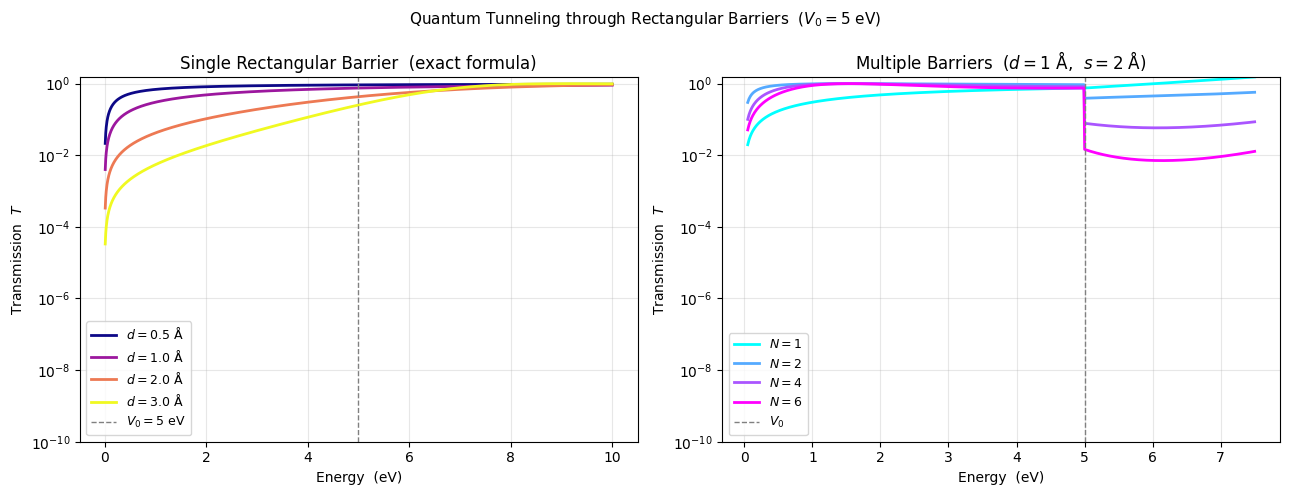

In [8]:
import numpy as np
import matplotlib.pyplot as plt

# --- Constants ---
hbar = 1.0545718e-34
m_e  = 9.10938e-31
eV   = 1.60218e-19

# --- Single rectangular barrier ---
V0_tun = 5.0 * eV       # barrier height
d_arr  = [0.5e-10, 1e-10, 2e-10, 3e-10]   # barrier widths (Å)

E_arr  = np.linspace(0.01 * eV, 2 * V0_tun, 2000)

def T_rect(E_arr, V0, d, m, hbar):
    """Exact transmission coefficient for a single rectangular barrier."""
    T = np.zeros_like(E_arr)
    for i, E in enumerate(E_arr):
        k = np.sqrt(2 * m * E) / hbar
        if E < V0:
            kap = np.sqrt(2 * m * (V0 - E)) / hbar
            sinh_val = np.sinh(kap * d)
            T[i] = 1.0 / (1 + ((k**2 + kap**2) / (2 * k * kap))**2 * sinh_val**2)
        else:
            kp = np.sqrt(2 * m * (E - V0)) / hbar
            sin_val = np.sin(kp * d)
            if abs(sin_val) < 1e-12:
                T[i] = 1.0
            else:
                T[i] = 1.0 / (1 + ((k**2 - kp**2) / (2 * k * kp))**2 * sin_val**2)
    return T

# --- Transfer Matrix for N identical barriers ---
def transfer_matrix_T(E, V0, d, s, N_barriers, m, hbar):
    """
    Transmission through N rectangular barriers each of height V0 and width d,
    separated by spacing s (well width).
    """
    k   = np.sqrt(2 * m * E) / hbar
    if E < V0:
        kap = np.sqrt(2 * m * (V0 - E)) / hbar

        # Single-barrier transfer matrix
        M11 = (np.cosh(kap * d)
               + 1j * (kap**2 - k**2) / (2 * k * kap) * np.sinh(kap * d))
        M12 =   1j * (kap**2 + k**2) / (2 * k * kap) * np.sinh(kap * d)
        M21 =  -1j * (kap**2 + k**2) / (2 * k * kap) * np.sinh(kap * d)
        M22 = np.conj(M11)
    else:
        kp = np.sqrt(2 * m * (E - V0)) / hbar
        M11 = (np.cos(kp * d)
               - 1j * (kp**2 - k**2) / (2 * k * kp) * np.sin(kp * d))
        M12 =   1j * (kp**2 + k**2) / (2 * k * kp) * np.sin(kp * d)
        M21 =  -1j * (kp**2 + k**2) / (2 * k * kp) * np.sin(kp * d)
        M22 = np.conj(M11)

    M_barrier = np.array([[M11, M12], [M21, M22]])

    # Free-propagation matrix through the well (spacing s)
    phase = np.exp(1j * k * s)
    M_well = np.array([[phase, 0], [0, np.conj(phase)]])

    M_total = np.eye(2, dtype=complex)
    for _ in range(N_barriers):
        M_total = M_well @ M_barrier @ M_total

    return 1.0 / abs(M_total[0, 0])**2

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: T vs E for various barrier widths
cmap_tun = plt.cm.plasma
for i, d in enumerate(d_arr):
    T = T_rect(E_arr, V0_tun, d, m_e, hbar)
    color = cmap_tun(i / (len(d_arr) - 1))
    axes[0].semilogy(E_arr / eV, np.maximum(T, 1e-15), color=color,
                     lw=2, label=f"$d = {d*1e10:.1f}$ Å")

axes[0].axvline(V0_tun / eV, color="gray", lw=1, ls="--", label=f"$V_0 = {V0_tun/eV:.0f}$ eV")
axes[0].set_xlabel("Energy  (eV)")
axes[0].set_ylabel("Transmission  $T$")
axes[0].set_title("Single Rectangular Barrier  (exact formula)")
axes[0].legend(fontsize=9)
axes[0].grid(True, which="both", alpha=0.3)
axes[0].set_ylim(1e-10, 1.5)

# Right: multiple barriers via transfer matrix
d_tm  = 1e-10    # barrier width 1 Å
s_tm  = 2e-10    # well width    2 Å
N_list = [1, 2, 4, 6]
E_tm  = np.linspace(0.05 * eV, 1.5 * V0_tun, 800)
cmap_nb = plt.cm.cool
for j, Nb in enumerate(N_list):
    T_multi = np.array([transfer_matrix_T(E, V0_tun, d_tm, s_tm, Nb, m_e, hbar)
                        for E in E_tm])
    axes[1].semilogy(E_tm / eV, np.maximum(T_multi, 1e-15),
                     color=cmap_nb(j / (len(N_list) - 1)),
                     lw=2, label=f"$N = {Nb}$")

axes[1].axvline(V0_tun / eV, color="gray", lw=1, ls="--", label=f"$V_0$")
axes[1].set_xlabel("Energy  (eV)")
axes[1].set_ylabel("Transmission  $T$")
axes[1].set_title(f"Multiple Barriers  ($d = {d_tm*1e10:.0f}$ Å,  $s = {s_tm*1e10:.0f}$ Å)")
axes[1].legend(fontsize=9)
axes[1].grid(True, which="both", alpha=0.3)
axes[1].set_ylim(1e-10, 1.5)

fig.suptitle(f"Quantum Tunneling through Rectangular Barriers  "
             f"($V_0 = {V0_tun/eV:.0f}$ eV)", fontsize=11)
fig.tight_layout()
plt.show()

---
## 9. Gaussian Wave Packet — Free-Particle Time Evolution (FFT)

An initial Gaussian wave packet centred at $x_0$ with momentum $k_0$ and
spatial width $\sigma_0$ is:

$$\psi(x,0) = \frac{1}{(2\pi\sigma_0^2)^{1/4}}
  \exp\!\left(-\frac{(x-x_0)^2}{4\sigma_0^2}\right)
  e^{ik_0 x}$$

Its momentum-space representation is Gaussian around $k_0$.
For a **free particle** the dispersion relation is $\omega(k) = \hbar k^2/(2m)$,
and the time-evolved state is obtained by the **split-step FFT** method:

$$\tilde\psi(k,t) = \tilde\psi(k,0)\,e^{-i\hbar k^2 t/(2m)}$$

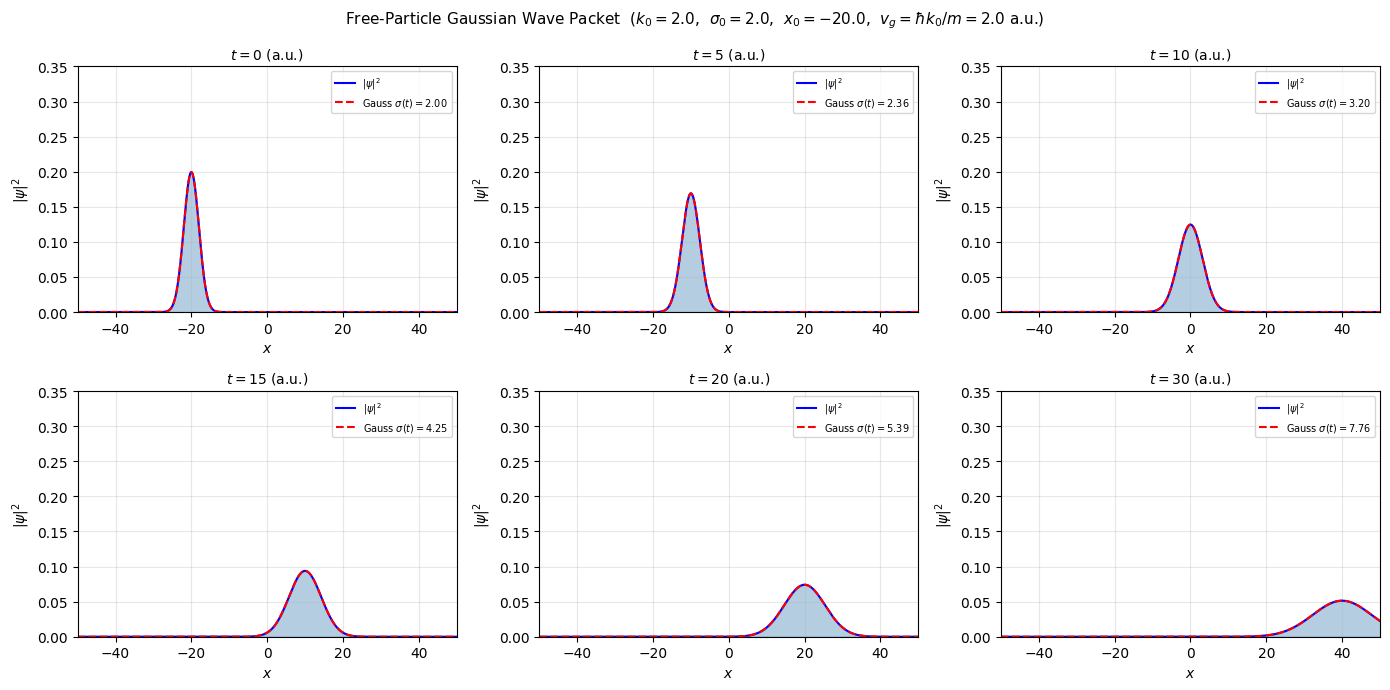

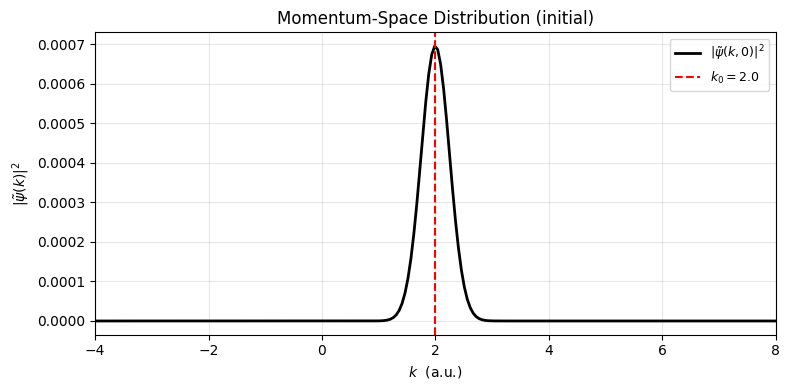

In [9]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation    # noqa — for documentation

# --- Parameters ---
hbar = 1.0
m_wp = 1.0              # natural units  (ℏ = m = 1)
Nx   = 2048
x_wp = np.linspace(-60, 60, Nx)
dx   = x_wp[1] - x_wp[0]
k_wp = np.fft.fftfreq(Nx, d=dx) * 2 * np.pi    # k-space grid

x0   =  -20.0          # initial position
k0   =   2.0           # central momentum (wave vector)
sig0 =   2.0           # initial spatial width

# --- Initial wave packet ---
psi0 = ((2 * np.pi * sig0**2)**(-0.25)
        * np.exp(-(x_wp - x0)**2 / (4 * sig0**2))
        * np.exp(1j * k0 * x_wp))

# --- Time evolution via FFT ---
def evolve(psi, k_arr, t, hbar, m):
    """Exact free-particle propagation in k-space."""
    psi_k  = np.fft.fft(psi)
    phase  = np.exp(-1j * hbar * k_arr**2 / (2 * m) * t)
    return np.fft.ifft(psi_k * phase)

t_snapshots = [0, 5, 10, 15, 20, 30]
cmap_wp  = plt.cm.plasma

fig, axes = plt.subplots(2, 3, figsize=(14, 7))
for ax, t_snap in zip(axes.flat, t_snapshots):
    psi_t = evolve(psi0, k_wp, t_snap, hbar, m_wp)
    prob  = np.abs(psi_t)**2

    # Analytic width: σ(t) = σ₀ √(1 + (ℏt/(2mσ₀²))²)
    sig_t = sig0 * np.sqrt(1 + (hbar * t_snap / (2 * m_wp * sig0**2))**2)
    x_cen = x0 + hbar * k0 / m_wp * t_snap   # group velocity centre

    # Gaussian envelope
    gauss = (1 / (np.sqrt(2 * np.pi) * sig_t)) * np.exp(-(x_wp - x_cen)**2 / (2 * sig_t**2))

    ax.fill_between(x_wp, prob, alpha=0.4, color="steelblue")
    ax.plot(x_wp, prob,  "b-",  lw=1.5, label=r"$|\psi|^2$")
    ax.plot(x_wp, gauss, "r--", lw=1.5, label=f"Gauss $\\sigma(t)={sig_t:.2f}$")
    ax.set_xlim(-50, 50)
    ax.set_ylim(0, 0.35)
    ax.set_title(f"$t = {t_snap}$ (a.u.)", fontsize=10)
    ax.set_xlabel("$x$")
    ax.set_ylabel("$|\\psi|^2$")
    ax.legend(fontsize=7, loc="upper right")
    ax.grid(True, alpha=0.3)

# Momentum-space snapshot
fig2, ax_k = plt.subplots(figsize=(8, 4))
psi_k_0 = np.fft.fftshift(np.fft.fft(psi0)) / Nx
k_shifted = np.fft.fftshift(k_wp)
ax_k.plot(k_shifted, np.abs(psi_k_0)**2, "k-", lw=2, label="$|\\tilde{\\psi}(k,0)|^2$")
ax_k.axvline(k0, color="red", ls="--", lw=1.5, label=f"$k_0 = {k0}$")
ax_k.set_xlabel("$k$  (a.u.)")
ax_k.set_ylabel("$|\\tilde{\\psi}(k)|^2$")
ax_k.set_title("Momentum-Space Distribution (initial)")
ax_k.set_xlim(-2 * k0, 4 * k0)
ax_k.legend(fontsize=9)
ax_k.grid(True, alpha=0.3)
fig2.tight_layout()

fig.suptitle(f"Free-Particle Gaussian Wave Packet  "
             f"($k_0 = {k0}$,  $\\sigma_0 = {sig0}$,  $x_0 = {x0}$,  "
             f"$v_g = \\hbar k_0/m = {hbar*k0/m_wp}$ a.u.)", fontsize=11)
fig.tight_layout()
plt.show()
plt.show()   # second figure

---
## 10. Variational Method — Upper Bound for the Ground-State Energy

The **variational principle** states that for any normalised trial state
$|\phi\rangle$ the expectation value of $\hat{H}$ provides an upper bound
to the true ground-state energy:

$$E_0 \le \langle\phi|\hat{H}|\phi\rangle$$

We apply this to two model systems:

**A) 1-D Infinite square well** — trial function $\phi(x;\alpha) = x^\alpha(L-x)^\alpha$

**B) Quantum harmonic oscillator** — trial function $\phi(x;b) = (b^2 - x^2)^2\,\Theta(b-|x|)$
   (polynomial cutoff)

By optimising the variational parameter we approach (but cannot beat) the
exact ground-state energy.

ISW — best variational energy: 1.003266 E₁  (exact = 1.000000 E₁)
ISW — optimal α = 1.113  (exact: 1.000 gives polynomial trial)

QHO — best variational energy: 1.044469 (ℏω/2)  (exact = 1.000000)
QHO — optimal b = 2.394 x_sc


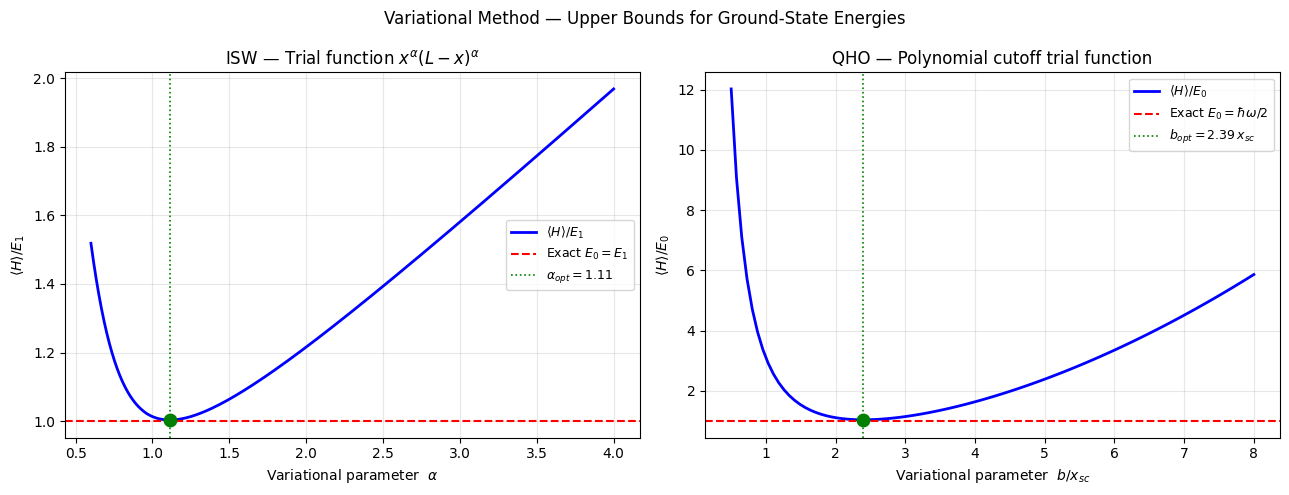

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import quad

# ============================================================
# A) Infinite square well: φ(x;α) = x^α (L - x)^α
# ============================================================
hbar = 1.0545718e-34
m_e  = 9.10938e-31
eV   = 1.60218e-19
L    = 1e-9

E1_exact = np.pi**2 * hbar**2 / (2 * m_e * L**2)

def variational_ISW(alpha):
    """
    Compute <H> / E1_exact for the trial function x^α(L-x)^α.
    The kinetic energy integral has a known closed form.
    """
    # <φ|φ> = B(2α+1, 2α+1) * L^(4α+1)  (beta function)
    from scipy.special import beta as beta_func
    norm2 = beta_func(2*alpha + 1, 2*alpha + 1) * L**(4*alpha + 1)

    # <φ|(-ℏ²/2m d²/dx²)|φ>  via integration by parts: = ℏ²/2m * <dφ/dx|dφ/dx>
    def integrand_T(x):
        dphi = alpha * x**(alpha-1) * (L-x)**alpha - alpha * x**alpha * (L-x)**(alpha-1)
        return dphi**2

    T_val, _ = quad(integrand_T, 0, L, limit=200)
    T_val   *= hbar**2 / (2 * m_e)

    return T_val / norm2

alphas = np.linspace(0.6, 4.0, 200)
E_var_ISW = np.array([variational_ISW(a) / E1_exact for a in alphas])

alpha_opt_ISW = alphas[np.argmin(E_var_ISW)]
E_opt_ISW     = np.min(E_var_ISW)
print(f"ISW — best variational energy: {E_opt_ISW:.6f} E₁  (exact = 1.000000 E₁)")
print(f"ISW — optimal α = {alpha_opt_ISW:.3f}  (exact: 1.000 gives polynomial trial)")

# ============================================================
# B) QHO: φ(x;b) = (b² - x²)² Θ(b - |x|)
# ============================================================
omega_var = 5e14    # rad/s
E0_QHO    = 0.5 * hbar * omega_var   # exact ℏω/2

def variational_QHO(b):
    """Compute <H>/E0_QHO for the polynomial cutoff trial function."""
    # <φ|φ>
    norm2, _ = quad(lambda x: (b**2 - x**2)**4, -b, b)

    # Kinetic energy <φ|(-ℏ²/2m)d²/dx²|φ>
    def integrand_T(x):
        phi   = (b**2 - x**2)**2
        d2phi = 2 * (b**2 - x**2) * (-2) + (-2*x)**2 * 4 * (b**2 - x**2)
        d2phi = 12 * x**2 * (b**2 - x**2) - 4 * (b**2 - x**2)**2
        # Second derivative of (b²-x²)²: d²/dx² = -4(3x²b² - b⁴ ... )
        # Compute directly: let f = (b²-x²)², f' = -4x(b²-x²), f'' = -4(b²-x²) + 8x²
        f2 = -4 * (b**2 - x**2) + 8 * x**2
        return phi * f2

    T_val, _ = quad(integrand_T, -b, b, limit=200)
    T_val   *= -hbar**2 / (2 * m_e)

    # Potential energy <φ|(mω²x²/2)|φ>
    V_val, _ = quad(lambda x: (b**2 - x**2)**4 * 0.5 * m_e * omega_var**2 * x**2, -b, b)

    return (T_val + V_val) / (norm2 * E0_QHO)

b_vals = np.linspace(0.5 * np.sqrt(hbar / (m_e * omega_var)),
                     8 * np.sqrt(hbar / (m_e * omega_var)), 100)
E_var_QHO = np.array([variational_QHO(b) for b in b_vals])

b_opt  = b_vals[np.argmin(E_var_QHO)]
E_opt_QHO = np.min(E_var_QHO)
print(f"\nQHO — best variational energy: {E_opt_QHO:.6f} (ℏω/2)  (exact = 1.000000)")
print(f"QHO — optimal b = {b_opt / np.sqrt(hbar/(m_e*omega_var)):.3f} x_sc")

# --- Figure ---
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(alphas, E_var_ISW, "b-", lw=2, label="$\\langle H\\rangle / E_1$")
axes[0].axhline(1.0, color="red", lw=1.5, ls="--", label="Exact $E_0 = E_1$")
axes[0].axvline(alpha_opt_ISW, color="green", lw=1.2, ls=":", label=f"$\\alpha_{{opt}}={alpha_opt_ISW:.2f}$")
axes[0].scatter([alpha_opt_ISW], [E_opt_ISW], s=80, color="green", zorder=5)
axes[0].set_xlabel("Variational parameter  $\\alpha$")
axes[0].set_ylabel("$\\langle H\\rangle / E_1$")
axes[0].set_title("ISW — Trial function $x^\\alpha(L-x)^\\alpha$")
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)

x_sc_qho = np.sqrt(hbar / (m_e * omega_var))
axes[1].plot(b_vals / x_sc_qho, E_var_QHO, "b-", lw=2, label="$\\langle H\\rangle / E_0$")
axes[1].axhline(1.0, color="red", lw=1.5, ls="--", label="Exact $E_0 = \\hbar\\omega/2$")
axes[1].axvline(b_opt / x_sc_qho, color="green", lw=1.2, ls=":",
                label=f"$b_{{opt}} = {b_opt/x_sc_qho:.2f}\\,x_{{sc}}$")
axes[1].scatter([b_opt / x_sc_qho], [E_opt_QHO], s=80, color="green", zorder=5)
axes[1].set_xlabel("Variational parameter  $b / x_{sc}$")
axes[1].set_ylabel("$\\langle H\\rangle / E_0$")
axes[1].set_title("QHO — Polynomial cutoff trial function")
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)

fig.suptitle("Variational Method — Upper Bounds for Ground-State Energies", fontsize=12)
fig.tight_layout()
plt.show()

---
## 11. Dirac Delta Potential — Single and Double δ-Function Wells

**Single well** $V(x) = -\alpha\,\delta(x)$ supports exactly **one** bound state:

$$E_b = -\frac{m\alpha^2}{2\hbar^2}, \qquad
  \psi(x) = \sqrt{\kappa}\,e^{-\kappa|x|}, \quad \kappa = \frac{m\alpha}{\hbar^2}$$

**Double well** $V(x) = -\alpha[\delta(x-a) + \delta(x+a)]$ has two bound states
(bonding and antibonding) whose energies satisfy the transcendental equations:

$$e^{-2\kappa a} = \pm\left(1 - \frac{\hbar^2\kappa}{m\alpha}\right)$$

— the $+$ sign gives the symmetric (bonding) ground state and the $-$ sign
gives the antisymmetric (antibonding) excited state.

Single delta well:
  κ = 4.0955e+19 m⁻¹
  E_b = -63905055801515483136.0000 eV

Double delta well  (a = 2.0/κ_single):
  Bonding:     κ = 4.0143e+19, E = -61396036159737061376.0000 eV


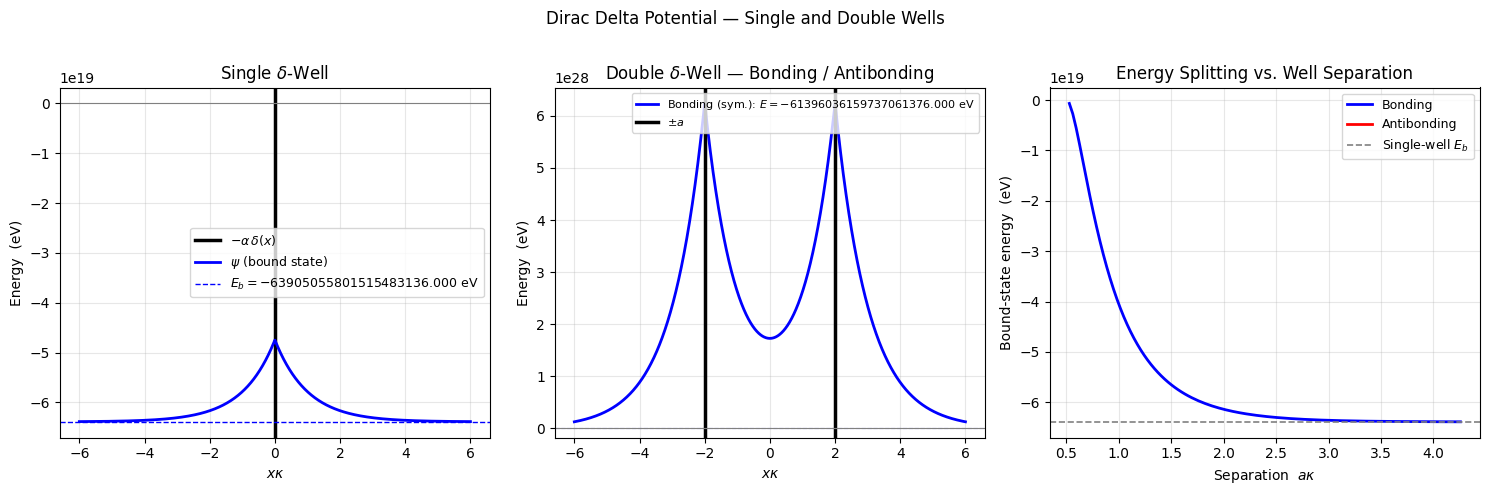

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import brentq

# --- Constants ---
hbar = 1.0545718e-34
m_e  = 9.10938e-31
eV   = 1.60218e-19

# Work in atomic units where ℏ = m_e = 1 for clarity
# α has units of [energy × length]; set α = 1 a.u.
alpha_delta = 5e-19   # J·m  (≈ 3 eV·Å, reasonable for a model well)
m_d = m_e

# --- Single delta well ---
kappa_single = m_d * alpha_delta / hbar**2
E_single     = -m_d * alpha_delta**2 / (2 * hbar**4 / m_d)
E_single     = -(m_d * alpha_delta**2) / (2 * hbar**2)

print(f"Single delta well:")
print(f"  κ = {kappa_single:.4e} m⁻¹")
print(f"  E_b = {E_single/eV:.4f} eV")

x_d  = np.linspace(-6 / kappa_single, 6 / kappa_single, 2000)
psi_single = np.sqrt(kappa_single) * np.exp(-kappa_single * np.abs(x_d))

# --- Double delta well ---
a_sep = 2.0 / kappa_single    # separation parameter

def bonding_eq(kappa):
    """Bonding state: e^{-2κa} = 1 - ℏ²κ/(mα)  →  LHS - RHS = 0"""
    return np.exp(-2 * kappa * a_sep) - (1 - hbar**2 * kappa / (m_d * alpha_delta))

def antibonding_eq(kappa):
    """Antibonding state: e^{-2κa} = -(1 - ℏ²κ/(mα))"""
    return np.exp(-2 * kappa * a_sep) + (1 - hbar**2 * kappa / (m_d * alpha_delta))

kap_max = m_d * alpha_delta / hbar**2 * 0.9999   # upper bound: free-atom κ

try:
    kap_bond = brentq(bonding_eq, 1e-6 * kap_max, kap_max)
    E_bond   = -hbar**2 * kap_bond**2 / (2 * m_d)
except ValueError:
    kap_bond, E_bond = None, None

try:
    kap_anti = brentq(antibonding_eq, 1e-6 * kap_max, kap_max)
    E_anti   = -hbar**2 * kap_anti**2 / (2 * m_d)
except ValueError:
    kap_anti, E_anti = None, None

print(f"\nDouble delta well  (a = {a_sep*kappa_single:.1f}/κ_single):")
if kap_bond:
    print(f"  Bonding:     κ = {kap_bond:.4e}, E = {E_bond/eV:.4f} eV")
if kap_anti:
    print(f"  Antibonding: κ = {kap_anti:.4e}, E = {E_anti/eV:.4f} eV")

def psi_double(kap, x, a, parity):
    """Analytical double-delta wavefunction (±)."""
    psi = np.zeros_like(x)
    inside  = np.abs(x) < a
    right   = x >=  a
    left    = x <= -a
    if parity == "even":
        A = np.cosh(kap * x[inside])    if inside.any() else np.array([])
        B = np.exp(-kap * x[right])
        C = np.exp( kap * x[left])
        scale = np.cosh(kap * a) * np.exp(kap * a)
        psi[inside] = np.cosh(kap * x[inside]) / scale
        psi[right]  = np.exp(-kap * x[right])
        psi[left]   = np.exp( kap * x[left])
    else:
        scale = np.sinh(kap * a) * np.exp(kap * a)
        psi[inside] = np.sinh(kap * x[inside]) / scale
        psi[right]  = np.exp(-kap * x[right])
        psi[left]   = -np.exp( kap * x[left])
    norm = np.sqrt(np.trapezoid(psi**2, x))
    return psi / norm

# --- Figure ---
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Panel 1: single well
scale_s = kappa_single * 0.4
axes[0].axvline( 0, color="k", lw=2.5, label="$-\\alpha\\,\\delta(x)$")
axes[0].plot(x_d * kappa_single, psi_single / np.max(psi_single) * scale_s + E_single / eV,
             "b-", lw=2, label=f"$\\psi$ (bound state)")
axes[0].axhline(E_single / eV, color="blue", lw=1, ls="--",
                label=f"$E_b = {E_single/eV:.3f}$ eV")
axes[0].axhline(0, color="gray", lw=0.8)
axes[0].set_xlabel("$x\\kappa$")
axes[0].set_ylabel("Energy  (eV)")
axes[0].set_title("Single $\\delta$-Well")
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)

# Panel 2: double well wavefunctions
for kap, E, par, color, lbl in [
    (kap_bond, E_bond, "even", "blue",   "Bonding (sym.)"),
    (kap_anti, E_anti, "odd",  "crimson","Antibonding (antisym.)")
]:
    if kap is None:
        continue
    psi_db = psi_double(kap, x_d, a_sep, par)
    sc = kappa_single * 0.35
    axes[1].plot(x_d * kappa_single, psi_db * sc + E / eV,
                 color=color, lw=2, label=f"{lbl}: $E={E/eV:.3f}$ eV")
    axes[1].axhline(E / eV, color=color, lw=0.8, ls="--", alpha=0.6)

axes[1].axvline( a_sep * kappa_single, color="k", lw=2.5)
axes[1].axvline(-a_sep * kappa_single, color="k", lw=2.5, label=f"$\\pm a$")
axes[1].axhline(0, color="gray", lw=0.8)
axes[1].set_xlabel("$x\\kappa$")
axes[1].set_ylabel("Energy  (eV)")
axes[1].set_title("Double $\\delta$-Well — Bonding / Antibonding")
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.3)

# Panel 3: splitting vs separation
a_arr = np.linspace(0.3 / kap_max, 10 / kap_max, 300)
E_b_arr, E_a_arr = [], []
for a_i in a_arr:
    def beq(k): return np.exp(-2*k*a_i) - (1 - hbar**2*k/(m_d*alpha_delta))
    def aeq(k): return np.exp(-2*k*a_i) + (1 - hbar**2*k/(m_d*alpha_delta))
    try:
        kb = brentq(beq, 1e-8*kap_max, kap_max*0.9999)
        E_b_arr.append(-hbar**2 * kb**2 / (2*m_d) / eV)
    except Exception:
        E_b_arr.append(np.nan)
    try:
        ka = brentq(aeq, 1e-8*kap_max, kap_max*0.9999)
        E_a_arr.append(-hbar**2 * ka**2 / (2*m_d) / eV)
    except Exception:
        E_a_arr.append(np.nan)

axes[2].plot(a_arr * kappa_single, E_b_arr, "b-",  lw=2, label="Bonding")
axes[2].plot(a_arr * kappa_single, E_a_arr, "r-",  lw=2, label="Antibonding")
axes[2].axhline(E_single / eV, color="gray", lw=1.2, ls="--", label="Single-well $E_b$")
axes[2].set_xlabel("Separation  $a\\kappa$")
axes[2].set_ylabel("Bound-state energy  (eV)")
axes[2].set_title("Energy Splitting vs. Well Separation")
axes[2].legend(fontsize=9)
axes[2].grid(True, alpha=0.3)

fig.suptitle("Dirac Delta Potential — Single and Double Wells", fontsize=12)
fig.tight_layout()
plt.show()

---
## 12. Infinite Spherical Well — Spherical Bessel Functions

A particle confined in a sphere of radius $R$ has boundary condition
$\psi(R) = 0$, requiring:

$$j_l(k_{nl}R) = 0 \implies k_{nl} = \frac{z_{nl}}{R}$$

where $z_{nl}$ is the $n$-th positive zero of the spherical Bessel function
$j_l$.  The energy levels are:

$$E_{nl} = \frac{\hbar^2 k_{nl}^2}{2m} = \frac{\hbar^2 z_{nl}^2}{2mR^2}$$

and the normalised radial eigenfunctions are:
$$u_{nl}(r) = r R_{nl}(r) = A_{nl}\,j_l(k_{nl}r)$$

Infinite Spherical Well energy levels  (R = 5 Å):
   State      z_nl      E (eV)
  1s:  z =  3.1416,  E = 1.5041 eV
  1p:  z =  4.4934,  E = 3.0770 eV
  1d:  z =  5.7635,  E = 5.0623 eV
  2s:  z =  6.2832,  E = 6.0165 eV
  1f:  z =  6.9879,  E = 7.4418 eV
  2p:  z =  7.7253,  E = 9.0951 eV
  2d:  z =  9.0950,  E = 12.6063 eV
  3s:  z =  9.4248,  E = 13.5371 eV
  2f:  z = 10.4171,  E = 16.5378 eV
  3p:  z = 10.9041,  E = 18.1202 eV
  3d:  z = 12.3229,  E = 23.1425 eV
  4s:  z = 12.5664,  E = 24.0659 eV


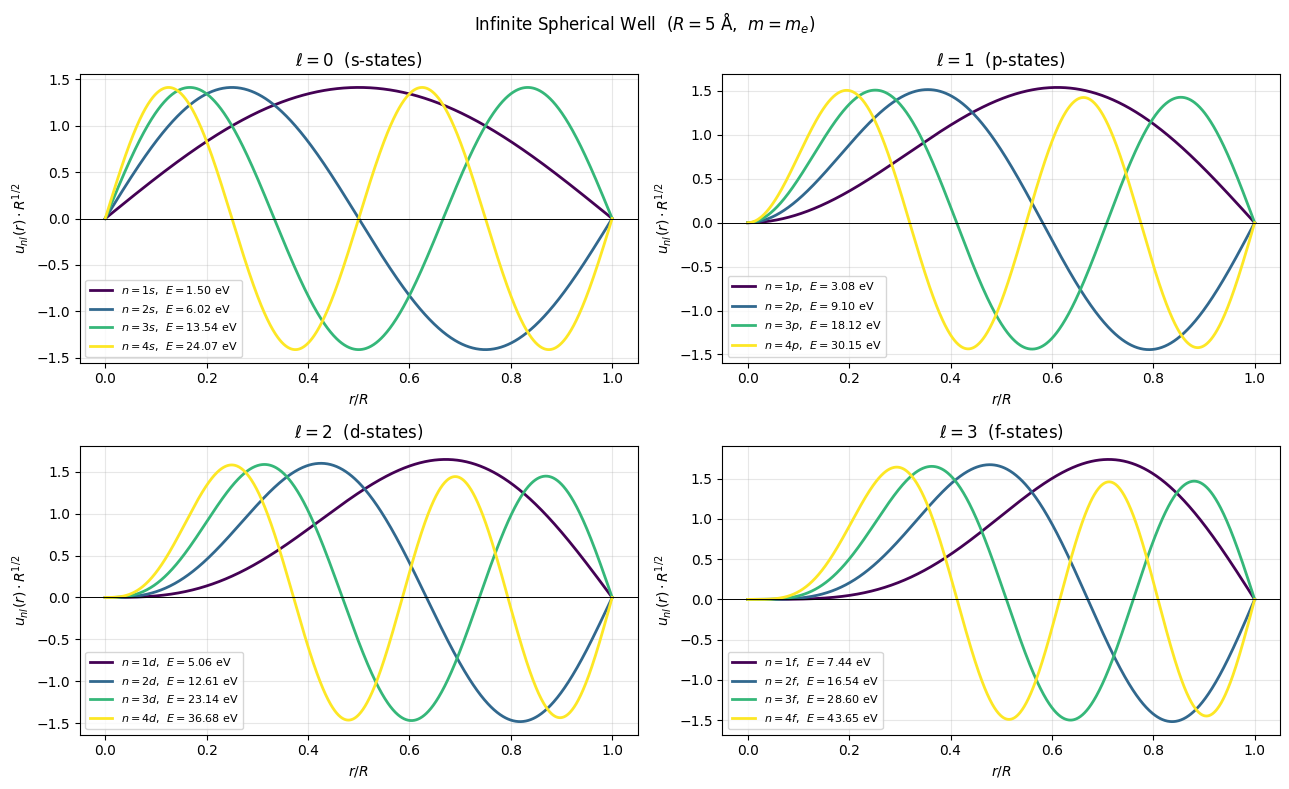

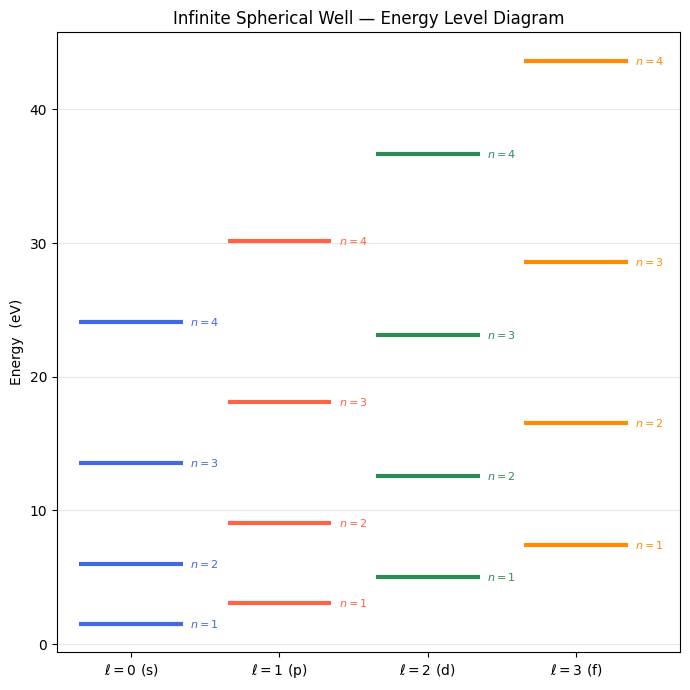

In [40]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import spherical_jn
from scipy.optimize import brentq

# --- Parameters ---
hbar = 1.0545718e-34
m_e  = 9.10938e-31
eV   = 1.60218e-19
R_sw = 5e-10        # sphere radius: 5 Å

E0_sw = hbar**2 / (2 * m_e * R_sw**2)   # energy scale

def find_bessel_zeros(l, n_zeros, x_max=60.0, n_scan=50000):
    """Find the first n_zeros positive zeros of j_l(x) by sign-change scanning."""
    x  = np.linspace(0.01, x_max, n_scan)
    jl = spherical_jn(l, x)
    zeros = []
    for i in range(len(jl) - 1):
        if np.sign(jl[i]) != np.sign(jl[i+1]):
            try:
                z = brentq(lambda xx: spherical_jn(l, xx), x[i], x[i+1])
                zeros.append(z)
            except Exception:
                pass
        if len(zeros) == n_zeros:
            break
    return np.array(zeros)

# Collect levels for l = 0, 1, 2, 3  (s, p, d, f)
l_labels = {0: "s", 1: "p", 2: "d", 3: "f"}
n_zeros  = 4
levels   = []   # (E_nl, n, l, z_nl)

for l in range(4):
    zeros = find_bessel_zeros(l, n_zeros)
    for n_idx, z in enumerate(zeros):
        E = E0_sw * z**2
        levels.append((E / eV, n_idx + 1, l, z))

levels.sort(key=lambda x: x[0])

print("Infinite Spherical Well energy levels  (R = 5 Å):")
print(f"{'State':>8}  {'z_nl':>8}  {'E (eV)':>10}")
for E_ev, n, l, z in levels[:12]:
    print(f"  {n}{l_labels[l]}:  z = {z:7.4f},  E = {E_ev:.4f} eV")

# --- Radial wavefunctions ---
r_sw = np.linspace(0, R_sw, 1000)
fig, axes = plt.subplots(2, 2, figsize=(13, 8))

cmap_sw = plt.cm.viridis
for ax, l in zip(axes.flat, range(4)):
    zeros = find_bessel_zeros(l, n_zeros)
    for n_idx, z in enumerate(zeros):
        k_nl   = z / R_sw
        u      = r_sw * spherical_jn(l, k_nl * r_sw)
        # Normalise: ∫₀^R u² dr = 1
        norm   = np.sqrt(np.trapezoid(u**2, r_sw))
        u     /= norm
        E_nl   = E0_sw * z**2 / eV
        color  = cmap_sw(n_idx / (n_zeros - 1))
        ax.plot(r_sw / R_sw, u * R_sw**0.5,
                color=color, lw=2,
                label=f"$n={n_idx+1}{l_labels[l]}$,  $E={E_nl:.2f}$ eV")

    ax.axhline(0, color="k", lw=0.7)
    ax.set_xlabel("$r / R$")
    ax.set_ylabel("$u_{nl}(r)\\cdot R^{1/2}$")
    ax.set_title(f"$\\ell = {l}$  ({l_labels[l]}-states)")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

fig.suptitle(f"Infinite Spherical Well  ($R = {R_sw*1e10:.0f}$ Å,  $m = m_e$)",
             fontsize=12)
fig.tight_layout()
plt.show()

# Energy level diagram
fig2, ax_el = plt.subplots(figsize=(7, 7))
colors_l = ["royalblue", "tomato", "seagreen", "darkorange"]
for E_ev, n, l, z in levels[:16]:
    ax_el.hlines(E_ev, l - 0.35, l + 0.35, color=colors_l[l], lw=3)
    ax_el.text(l + 0.4, E_ev, f"$n={n}$", va="center", fontsize=8, color=colors_l[l])

ax_el.set_xticks(range(4))
ax_el.set_xticklabels(["$\\ell=0$ (s)", "$\\ell=1$ (p)", "$\\ell=2$ (d)", "$\\ell=3$ (f)"])
ax_el.set_ylabel("Energy  (eV)")
ax_el.set_title("Infinite Spherical Well — Energy Level Diagram")
ax_el.set_xlim(-0.5, 3.7)
ax_el.grid(True, axis="y", alpha=0.3)
fig2.tight_layout()
plt.show()

---
## 13. Rigid Rotor — Angular Momentum Eigenvalues $\hat{L}^2$

The quantum rigid rotor (a particle constrained to a sphere of radius $R$)
has eigenstates given by the spherical harmonics $Y_l^m(\theta,\phi)$ with:

$$\hat{L}^2 Y_l^m = \hbar^2 l(l+1)\,Y_l^m, \qquad
  \hat{L}_z Y_l^m = m\hbar\,Y_l^m$$

$$E_l = \frac{\hbar^2 l(l+1)}{2I}, \qquad I = mR^2$$

Each level $l$ has $(2l+1)$-fold degeneracy.  We visualise the spherical
harmonics $|Y_l^m|^2$ as 3-D polar plots and the rotational energy spectrum.

Rigid-rotor energy levels:
  l=0: E = 0.0000 eV  (degeneracy 1)
  l=1: E = 7.6200 eV  (degeneracy 3)
  l=2: E = 22.8599 eV  (degeneracy 5)
  l=3: E = 45.7197 eV  (degeneracy 7)
  l=4: E = 76.1995 eV  (degeneracy 9)
  l=5: E = 114.2993 eV  (degeneracy 11)


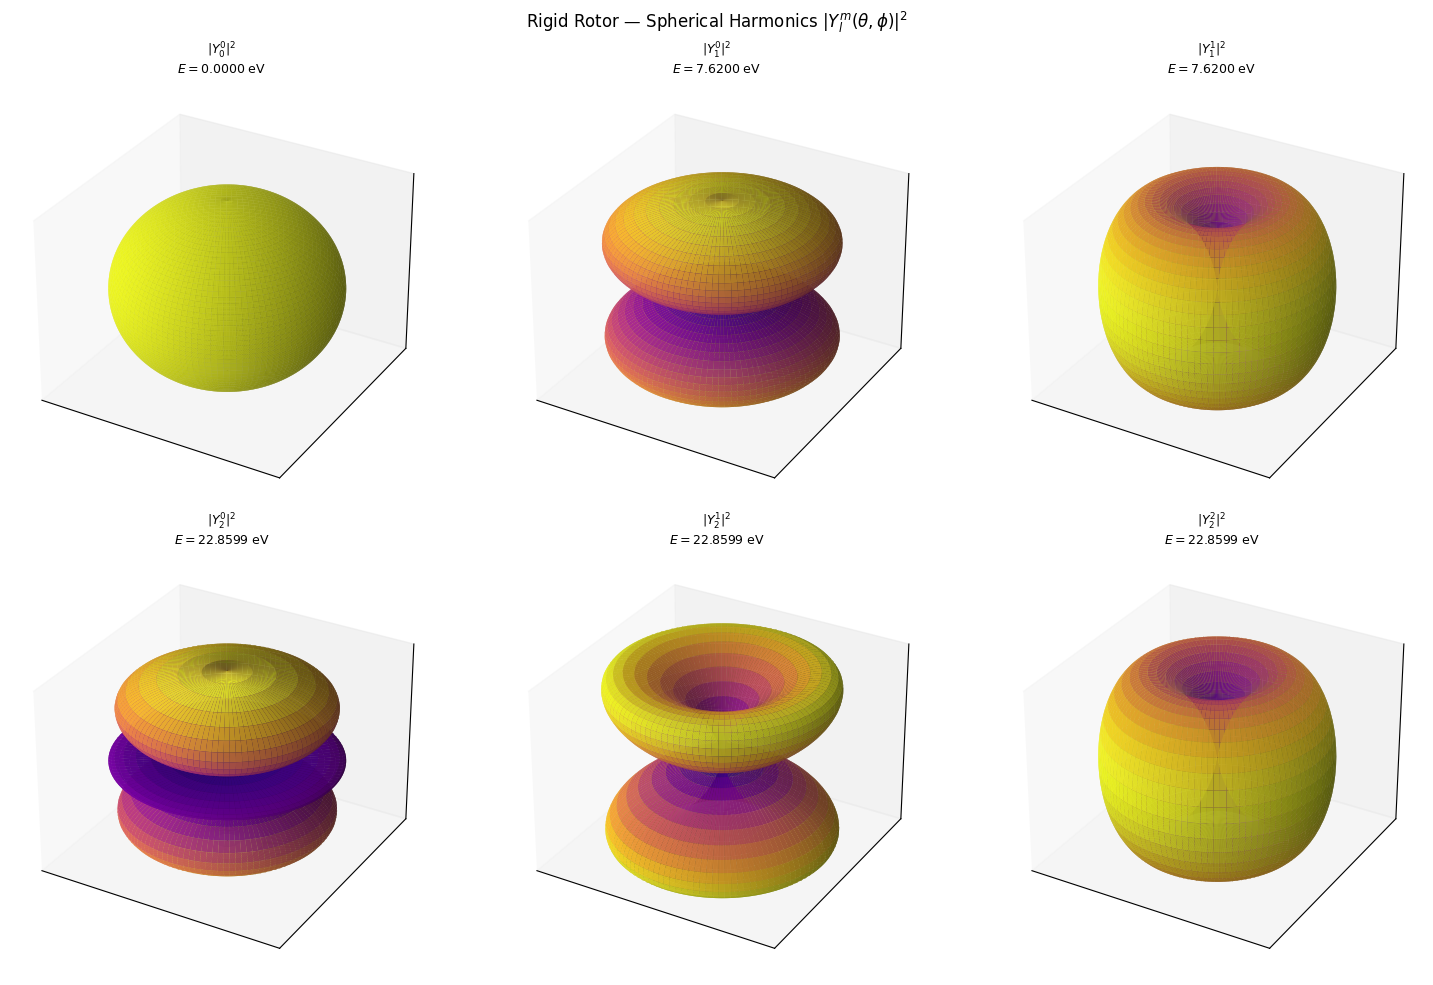

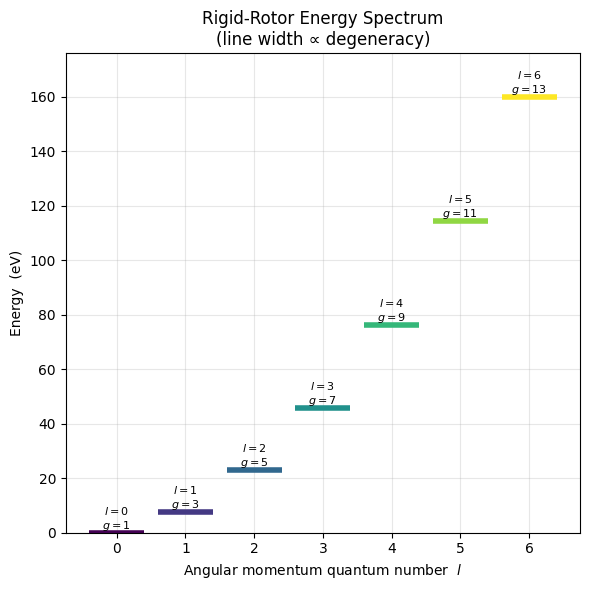

In [42]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import sph_harm_y

# --- Parameters ---
hbar = 1.0545718e-34
m_e  = 9.10938e-31
eV   = 1.60218e-19
I_rr = m_e * (1e-10)**2     # moment of inertia (electron on 1-Å ring)
B_rot = hbar**2 / (2 * I_rr)   # rotational constant

print("Rigid-rotor energy levels:")
for l in range(6):
    E = B_rot * l * (l + 1)
    print(f"  l={l}: E = {E/eV:.4f} eV  (degeneracy {2*l+1})")

# --- Spherical harmonic polar plots ---
theta = np.linspace(0, np.pi,  120)
phi   = np.linspace(0, 2*np.pi, 240)
THETA, PHI = np.meshgrid(theta, phi)

fig = plt.figure(figsize=(15, 10))
states_rr = [(0,0), (1,0),(1,1), (2,0),(2,1),(2,2)]

for idx, (l, m) in enumerate(states_rr):
    ax = fig.add_subplot(2, 3, idx+1, projection="3d")
    Y  = sph_harm_y(l, m, THETA, PHI)
    R  = np.abs(Y)**2

    X  = R * np.sin(THETA) * np.cos(PHI)
    Y3 = R * np.sin(THETA) * np.sin(PHI)
    Z  = R * np.cos(THETA)

    norm_R = R / (R.max() + 1e-20)
    ax.plot_surface(X, Y3, Z, facecolors=plt.cm.plasma(norm_R),
                    rstride=2, cstride=2, alpha=0.9, linewidth=0)
    ax.set_title(f"$|Y_{{{l}}}^{{{m}}}|^2$\n$E = {B_rot*l*(l+1)/eV:.4f}$ eV",
                 fontsize=9)
    ax.set_xticks([]); ax.set_yticks([]); ax.set_zticks([])

fig.suptitle("Rigid Rotor — Spherical Harmonics $|Y_l^m(\\theta,\\phi)|^2$",
             fontsize=12)
fig.tight_layout()
plt.show()

# --- Energy level diagram with degeneracy ---
fig2, ax2 = plt.subplots(figsize=(6, 6))
for l in range(7):
    E_l = B_rot * l * (l + 1) / eV
    ax2.hlines(E_l, l - 0.4, l + 0.4, color=plt.cm.viridis(l / 6), lw=4)
    ax2.text(l, E_l + 0.00005, f"$l={l}$\n$g={2*l+1}$",
             ha="center", va="bottom", fontsize=8)

ax2.set_xlabel("Angular momentum quantum number  $l$")
ax2.set_ylabel("Energy  (eV)")
ax2.set_title("Rigid-Rotor Energy Spectrum\n(line width ∝ degeneracy)")
ax2.set_ylim(0, 1.1 * max(B_rot * l * (l + 1) / eV for l in range(7)))
ax2.grid(True, alpha=0.3)
fig2.tight_layout()
plt.show()

---
## 14. Spin-½ Precession — Bloch Sphere and Rabi Oscillations

A spin-½ particle in a magnetic field $\mathbf{B} = B_0\hat{z}$ has Hamiltonian
$\hat{H} = -\gamma\,\hbar\,\mathbf{S}\cdot\mathbf{B}$ and precesses at the
**Larmor frequency** $\omega_0 = \gamma B_0$.

Adding a resonant transverse field $B_1\cos(\omega t)$ drives **Rabi oscillations**
between $|\uparrow\rangle$ and $|\downarrow\rangle$.  In the rotating frame the
effective Hamiltonian gives:

$$P_{\uparrow\to\downarrow}(t) = \frac{\Omega_1^2}{\Omega_R^2}
  \sin^2\!\left(\frac{\Omega_R t}{2}\right), \qquad
  \Omega_R = \sqrt{(\omega_0 - \omega)^2 + \Omega_1^2}$$

where $\Omega_1 = \gamma B_1$ is the Rabi frequency.

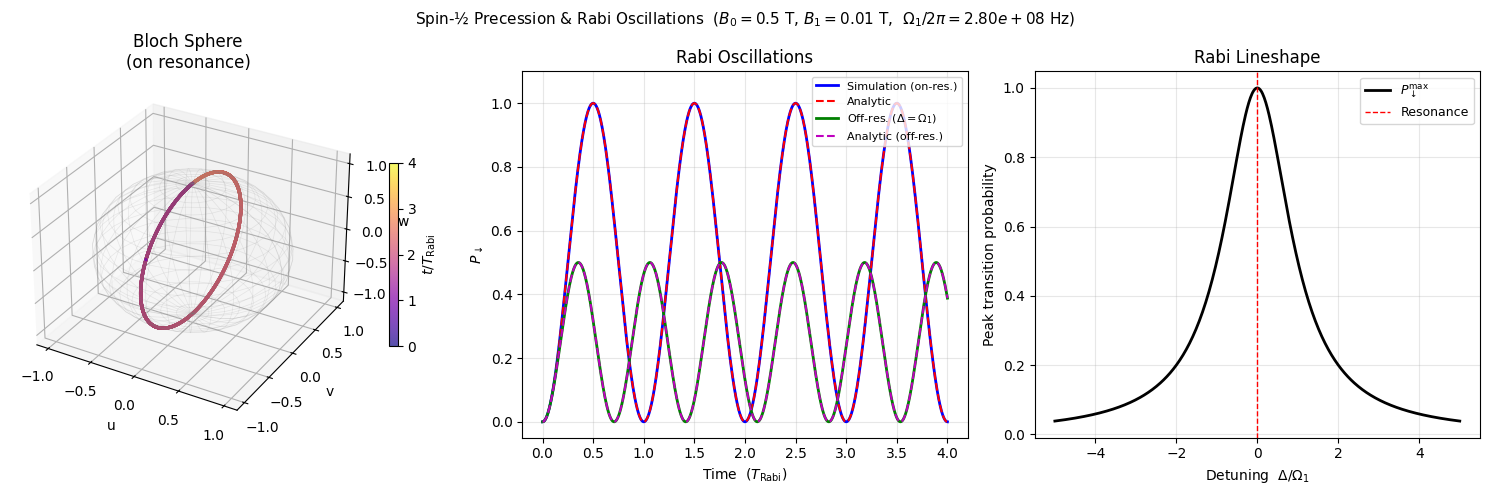

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa

# --- Parameters (electron, in SI) ---
hbar   = 1.0545718e-34
gamma  = 1.760859e11    # electron gyromagnetic ratio (rad/s/T)
B0     = 0.5            # static field (T)
B1     = 0.01           # drive amplitude (T)
omega0 = gamma * B0     # Larmor frequency

Omega1 = gamma * B1     # Rabi frequency (on resonance)
T_rabi = 2 * np.pi / Omega1   # one Rabi period

t_arr  = np.linspace(0, 4 * T_rabi, 5000)

# --- Bloch vector evolution (exact, rotating-frame RK4) ---
# State vector [u, v, w] where w = <σ_z>, u+iv = coherence
# Equations on resonance: du/dt = 0, dv/dt = Ω₁ w, dw/dt = -Ω₁ v
def bloch_rhs(t, state, omega_drive, omega0, Omega1):
    u, v, w = state
    delta = omega0 - omega_drive    # detuning
    du = -delta * v
    dv =  delta * u - Omega1 * w
    dw =  Omega1 * v
    return np.array([du, dv, dw])

def rk4_bloch(state0, t_arr, omega_drive, omega0, Omega1):
    states = np.zeros((len(t_arr), 3))
    states[0] = state0
    for i in range(1, len(t_arr)):
        dt = t_arr[i] - t_arr[i-1]
        t  = t_arr[i-1]
        s  = states[i-1]
        k1 = bloch_rhs(t,        s,             omega_drive, omega0, Omega1)
        k2 = bloch_rhs(t+dt/2,   s+dt*k1/2,    omega_drive, omega0, Omega1)
        k3 = bloch_rhs(t+dt/2,   s+dt*k2/2,    omega_drive, omega0, Omega1)
        k4 = bloch_rhs(t+dt,     s+dt*k3,       omega_drive, omega0, Omega1)
        states[i] = s + dt*(k1+2*k2+2*k3+k4)/6
    return states

# Initial state: spin-up  (u,v,w) = (0, 0, 1)
s0 = np.array([0.0, 0.0, 1.0])

# On resonance
states_on  = rk4_bloch(s0, t_arr, omega0, omega0, Omega1)
# Off resonance (detuning = Ω₁)
states_off = rk4_bloch(s0, t_arr, omega0 + Omega1, omega0, Omega1)

P_down_on  = (1 - states_on[:, 2])  / 2
P_down_off = (1 - states_off[:, 2]) / 2

# Analytic Rabi formula
OmR_on  = Omega1
OmR_off = np.sqrt(Omega1**2 + Omega1**2)
P_rabi_analytic_on  = (Omega1/OmR_on)**2  * np.sin(OmR_on  * t_arr / 2)**2
P_rabi_analytic_off = (Omega1/OmR_off)**2 * np.sin(OmR_off * t_arr / 2)**2

fig = plt.figure(figsize=(15, 5))

# Panel 1: Bloch sphere trajectory (on resonance)
ax3d = fig.add_subplot(131, projection="3d")
u, v, w = states_on[:, 0], states_on[:, 1], states_on[:, 2]
sc = ax3d.scatter(u, v, w, c=t_arr/T_rabi, cmap="plasma", s=2, alpha=0.7)
# Draw sphere wireframe
phi_s, th_s = np.mgrid[0:2*np.pi:30j, 0:np.pi:20j]
xs = np.sin(th_s)*np.cos(phi_s); ys = np.sin(th_s)*np.sin(phi_s); zs = np.cos(th_s)
ax3d.plot_wireframe(xs, ys, zs, color="gray", alpha=0.15, lw=0.5)
ax3d.set_xlabel("u"); ax3d.set_ylabel("v"); ax3d.set_zlabel("w")
ax3d.set_title("Bloch Sphere\n(on resonance)")
fig.colorbar(sc, ax=ax3d, shrink=0.5, label="$t/T_{\\rm Rabi}$")

# Panel 2: Rabi oscillations
ax2 = fig.add_subplot(132)
ax2.plot(t_arr / T_rabi, P_down_on,  "b-",  lw=2, label="Simulation (on-res.)")
ax2.plot(t_arr / T_rabi, P_rabi_analytic_on, "r--", lw=1.5, label="Analytic")
ax2.plot(t_arr / T_rabi, P_down_off, "g-",  lw=2, label=f"Off-res. ($\\Delta=\\Omega_1$)")
ax2.plot(t_arr / T_rabi, P_rabi_analytic_off,"m--", lw=1.5, label="Analytic (off-res.)")
ax2.set_xlabel("Time  ($T_{\\rm Rabi}$)")
ax2.set_ylabel("$P_{\\downarrow}$")
ax2.set_title("Rabi Oscillations")
ax2.set_ylim(-0.05, 1.1)
ax2.legend(fontsize=8)
ax2.grid(True, alpha=0.3)

# Panel 3: Rabi lineshape vs detuning
ax3 = fig.add_subplot(133)
deltas = np.linspace(-5 * Omega1, 5 * Omega1, 500)
OmR    = np.sqrt(deltas**2 + Omega1**2)
P_max  = (Omega1 / OmR)**2
ax3.plot(deltas / Omega1, P_max, "k-", lw=2, label="$P_{\\downarrow}^{\\rm max}$")
ax3.axvline(0, color="red", lw=1, ls="--", label="Resonance")
ax3.set_xlabel("Detuning  $\\Delta/\\Omega_1$")
ax3.set_ylabel("Peak transition probability")
ax3.set_title("Rabi Lineshape")
ax3.legend(fontsize=9)
ax3.grid(True, alpha=0.3)

fig.suptitle(f"Spin-½ Precession & Rabi Oscillations  "
             f"($B_0={B0}$ T, $B_1={B1}$ T,  "
             f"$\\Omega_1/2\\pi = {Omega1/(2*np.pi):.2e}$ Hz)", fontsize=11)
fig.tight_layout()
plt.show()

---
## 15. Perturbation Theory — 1st and 2nd Order Corrections to the ISW

We add a perturbation $H' = \lambda V'(x)$ to the infinite square well and
compute energy corrections via Rayleigh–Schrödinger perturbation theory:

$$E_n^{(1)} = \langle n^{(0)} | H' | n^{(0)}\rangle$$

$$E_n^{(2)} = \sum_{m\ne n}
  \frac{|\langle m^{(0)}|H'|n^{(0)}\rangle|^2}{E_n^{(0)} - E_m^{(0)}}$$

We consider two perturbations:
- **Linear ramp:**  $V'(x) = V_0\, x/L$  (exact result known)
- **Gaussian bump:**  $V'(x) = V_0\,\exp\!\left[-\frac{(x-L/2)^2}{2w^2}\right]$


Linear ramp  (λ = 0.2):
   n     E⁰ (eV)    E¹ (meV)    E² (meV)    E_total (eV)
   1      0.3760    500.0000     -1.1520        0.474878
   2      1.5041    500.0000      0.3435        1.604462
   3      3.3843    500.0000      0.2047        3.484470
   4      6.0165    500.0000      0.1254        6.116598
   5      9.4007    500.0000      0.0833        9.500821
   6     13.5371    500.0000      0.0590       13.637121
   7     18.4254    500.0000      0.0438       18.525490
   8     24.0659    500.0000      0.0338       24.165923

Gaussian bump  (λ = 0.2):
   n     E⁰ (eV)    E¹ (meV)    E² (meV)    E_total (eV)
   1      0.3760    912.8482     -5.8904        0.552709
   2      1.5041    273.7034     -1.0997        1.557759
   3      3.3843    586.1622      4.0330        3.505531
   4      6.0165    480.0197     -0.0629        6.112413
   5      9.4007    504.9311      0.8194        9.502543
   6     13.5371    500.9144      0.2897       13.637535
   7     18.4254    501.3571      0.

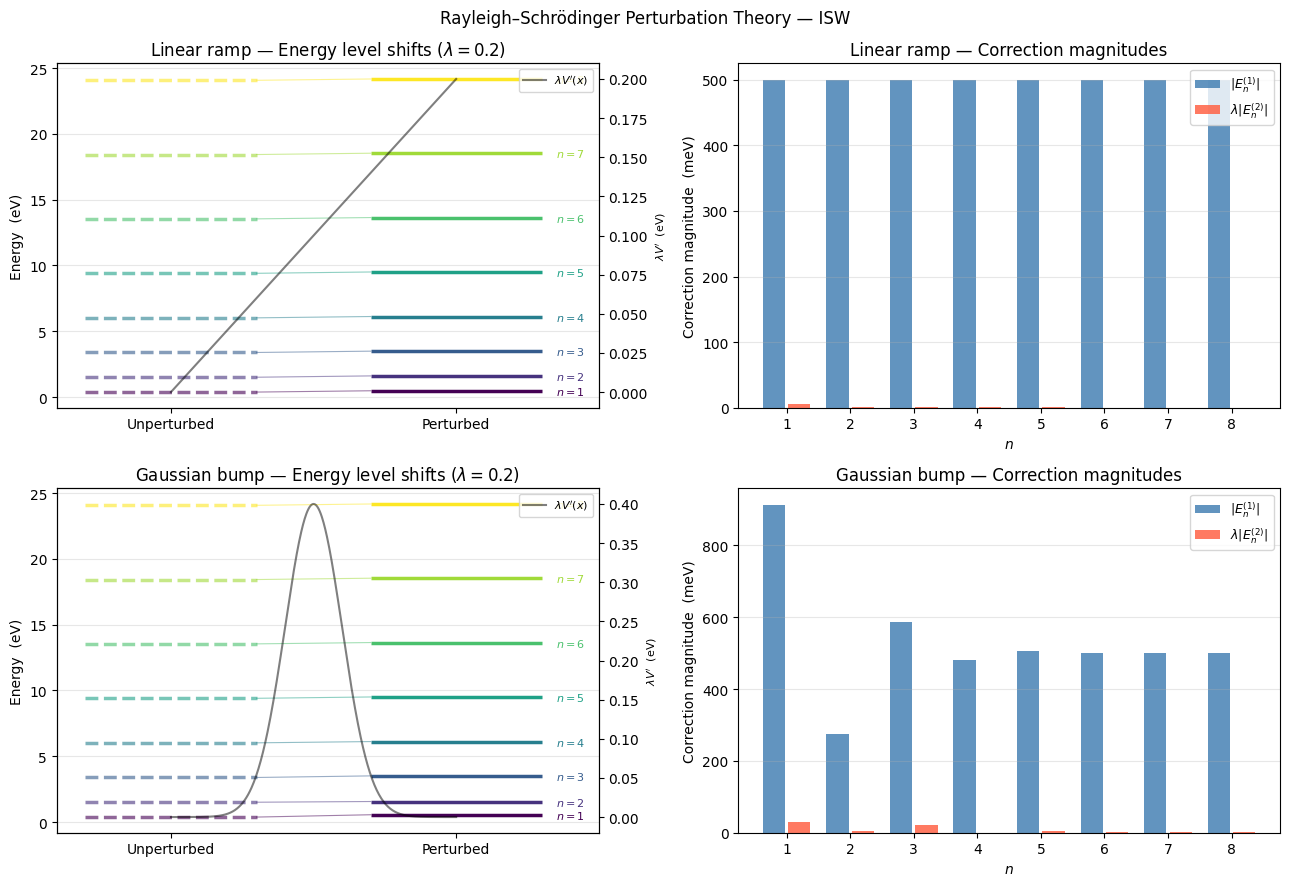

In [50]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import quad

# --- Parameters ---
hbar  = 1.0545718e-34
m_e   = 9.10938e-31
eV    = 1.60218e-19
L_pt  = 1e-9          # box length
E1    = np.pi**2 * hbar**2 / (2 * m_e * L_pt**2)
N_max = 30            # number of unperturbed states
lam   = 0.2           # perturbation strength

def psi_n(n, x, L):
    return np.sqrt(2 / L) * np.sin(n * np.pi * x / L)

def E_n0(n):
    return n**2 * E1

# Matrix elements  <m|V'|n>
def matrix_element(m, n, V_func, L, N_pts=2000):
    x  = np.linspace(0, L, N_pts)
    integrand = psi_n(m, x, L) * V_func(x) * psi_n(n, x, L)
    return np.trapezoid(integrand, x)

# Perturbations
def V_ramp(x):    return eV * x / L_pt             # 1 eV ramp
def V_gauss(x):
    w = 0.1 * L_pt
    return 2 * eV * np.exp(-(x - L_pt/2)**2 / (2 * w**2))

n_list  = np.arange(1, 9)
results = {}

for V_func, label in [(V_ramp, "Linear ramp"), (V_gauss, "Gaussian bump")]:
    E1st = np.array([matrix_element(n, n, V_func, L_pt) for n in n_list])

    E2nd = np.zeros(len(n_list))
    for i, n in enumerate(n_list):
        for m in range(1, N_max + 1):
            if m == n:
                continue
            Vmn = matrix_element(m, n, V_func, L_pt)
            E2nd[i] += Vmn**2 / (E_n0(n) - E_n0(m))

    results[label] = (E1st, E2nd)
    print(f"\n{label}  (λ = {lam}):")
    print(f"{'n':>4}  {'E⁰ (eV)':>10}  {'E¹ (meV)':>10}  {'E² (meV)':>10}  {'E_total (eV)':>14}")
    for i, n in enumerate(n_list):
        E0_ev  = E_n0(n) / eV
        E1_mev = E1st[i] / eV * 1e3
        E2_mev = lam**2 * E2nd[i] / eV * 1e3
        E_tot  = E_n0(n)/eV + lam*E1st[i]/eV + lam**2*E2nd[i]/eV
        print(f"  {n:2d}  {E0_ev:10.4f}  {E1_mev:10.4f}  {E2_mev:10.4f}  {E_tot:14.6f}")

# --- Figure ---
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

x_pt  = np.linspace(0, L_pt, 500)

for row, (V_func, label) in enumerate([(V_ramp, "Linear ramp"), (V_gauss, "Gaussian bump")]):
    E1st, E2nd = results[label]

    # Left: unperturbed vs perturbed energy levels
    ax = axes[row, 0]
    for i, n in enumerate(n_list):
        E0_ev = E_n0(n) / eV
        E_corr = (E_n0(n) + lam*E1st[i] + lam**2*E2nd[i]) / eV
        color = plt.cm.viridis(i / (len(n_list)-1))
        ax.hlines(E0_ev,  0.2, 0.8, color=color, lw=2.5, ls="--", alpha=0.6)
        ax.hlines(E_corr, 1.2, 1.8, color=color, lw=2.5)
        ax.plot([0.8, 1.2], [E0_ev, E_corr], color=color, lw=0.8, alpha=0.5)
        ax.text(1.85, E_corr, f"$n={n}$", va="center", fontsize=8, color=color)

    ax.set_xticks([0.5, 1.5]); ax.set_xticklabels(["Unperturbed", "Perturbed"])
    ax.set_ylabel("Energy  (eV)")
    ax.set_title(f"{label} — Energy level shifts ($\\lambda={lam}$)")
    ax.grid(True, axis="y", alpha=0.3)

    # Right: magnitude of corrections
    ax2 = axes[row, 1]
    ax2.bar(n_list - 0.2, np.abs(E1st) / eV * 1e3,      width=0.35,
            label="$|E_n^{(1)}|$", color="steelblue", alpha=0.85)
    ax2.bar(n_list + 0.2, lam * np.abs(E2nd) / eV * 1e3, width=0.35,
            label="$\\lambda|E_n^{(2)}|$", color="tomato", alpha=0.85)
    ax2.set_xlabel("$n$")
    ax2.set_ylabel("Correction magnitude  (meV)")
    ax2.set_title(f"{label} — Correction magnitudes")
    ax2.set_xticks(n_list)
    ax2.legend(fontsize=9)
    ax2.grid(True, axis="y", alpha=0.3)

# Overlay potential shapes
for ax, V_func in zip([axes[0,0], axes[1,0]], [V_ramp, V_gauss]):
    ax2_twin = ax.twinx()
    ax2_twin.plot(0.5 + x_pt / L_pt,
                  V_func(x_pt) / eV * lam, "k-", lw=1.5, alpha=0.5, label="$\\lambda V'(x)$")
    ax2_twin.set_ylabel("$\\lambda V'$  (eV)", fontsize=8)
    ax2_twin.legend(fontsize=8, loc="upper right")
    ax2_twin.set_xlim(0.1, 2)

fig.suptitle("Rayleigh–Schrödinger Perturbation Theory — ISW", fontsize=12)
fig.tight_layout()
plt.show()

---
## 16. WKB Approximation — Tunneling through an Arbitrary Barrier

The **WKB (Wentzel–Kramers–Brillouin)** approximation gives the tunneling
transmission coefficient through a classically forbidden region $[x_1, x_2]$
as:

$$T_{\rm WKB} \approx \exp\!\left(-2\int_{x_1}^{x_2}
  \kappa(x)\,dx\right), \qquad
  \kappa(x) = \frac{\sqrt{2m[V(x)-E]}}{\hbar}$$

We compare the WKB result against the exact transfer-matrix result for
three barrier shapes: rectangular, triangular (Fowler–Nordheim), and
parabolic (inverted oscillator).

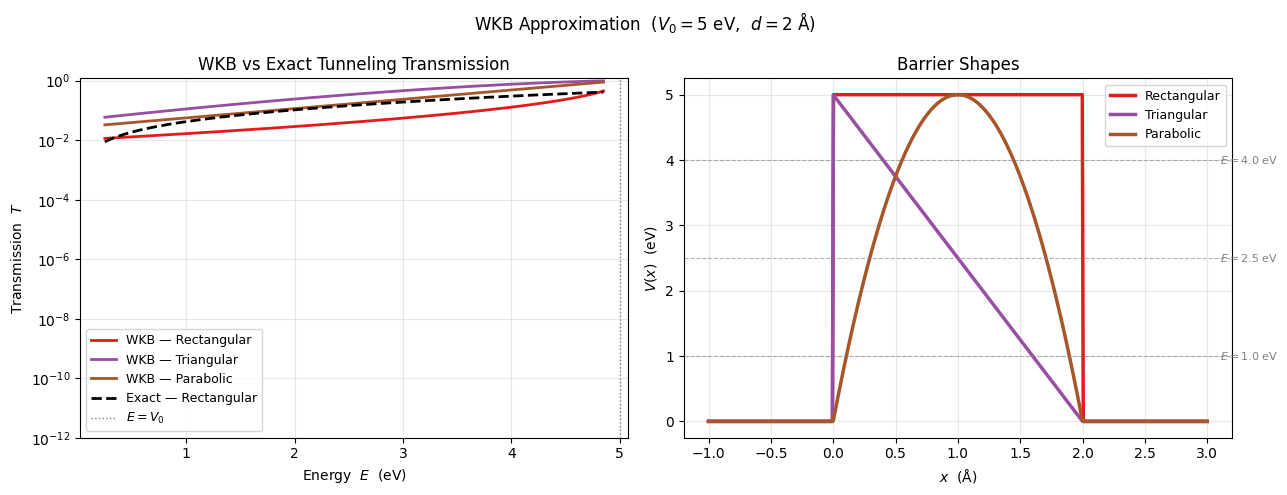

In [51]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import quad

# --- Constants ---
hbar = 1.0545718e-34
m_e  = 9.10938e-31
eV   = 1.60218e-19

V0_wkb = 5.0 * eV
d_wkb  = 2e-10   # barrier width

# --- Barrier shapes ---
def V_rect(x):
    return np.where((x >= 0) & (x <= d_wkb), V0_wkb, 0.0)

def V_tri(x):
    """Triangular (linear) barrier from V0 at x=0 to 0 at x=d."""
    return np.where((x >= 0) & (x <= d_wkb), V0_wkb * (1 - x / d_wkb), 0.0)

def V_para(x):
    """Parabolic barrier peaking at x = d/2."""
    xc = d_wkb / 2
    return np.where((x >= 0) & (x <= d_wkb),
                    V0_wkb * (1 - ((x - xc) / xc)**2), 0.0)

barriers = [("Rectangular", V_rect), ("Triangular", V_tri), ("Parabolic", V_para)]
E_arr_wkb = np.linspace(0.05 * V0_wkb, 0.97 * V0_wkb, 300)

# --- WKB tunneling integral ---
def T_WKB(E, V_func, d, m, hbar, N=5000):
    x  = np.linspace(0, d, N)
    Vx = np.array([V_func(xi) for xi in x])
    diff = 2 * m * (Vx - E)
    kappa = np.sqrt(np.maximum(diff, 0)) / hbar
    integral = np.trapezoid(kappa, x)
    return np.exp(-2 * integral)

# --- Exact transfer-matrix for rectangular barrier (reference) ---
def T_rect_exact(E, V0, d, m, hbar):
    k   = np.sqrt(2 * m * E) / hbar
    kap = np.sqrt(2 * m * (V0 - E)) / hbar
    return 1.0 / (1 + ((k**2 + kap**2)**2 / (4 * k**2 * kap**2)) * np.sinh(kap * d)**2)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
cmap_wkb = plt.cm.Set1

for i, (name, V_func) in enumerate(barriers):
    color = cmap_wkb(i / 3)
    T_wkb = np.array([T_WKB(E, V_func, d_wkb, m_e, hbar) for E in E_arr_wkb])
    axes[0].semilogy(E_arr_wkb / eV, T_wkb, color=color, lw=2, label=f"WKB — {name}")

# Exact for rectangle
T_exact_rect = np.array([T_rect_exact(E, V0_wkb, d_wkb, m_e, hbar) for E in E_arr_wkb])
axes[0].semilogy(E_arr_wkb / eV, T_exact_rect, "k--", lw=2, label="Exact — Rectangular")
axes[0].axvline(V0_wkb / eV, color="gray", lw=1, ls=":", label="$E = V_0$")
axes[0].set_xlabel("Energy  $E$  (eV)")
axes[0].set_ylabel("Transmission  $T$")
axes[0].set_title("WKB vs Exact Tunneling Transmission")
axes[0].legend(fontsize=9)
axes[0].grid(True, which="both", alpha=0.3)
axes[0].set_ylim(1e-12, 1.2)

# Right panel: barrier shapes
x_plot = np.linspace(-0.5*d_wkb, 1.5*d_wkb, 500)
for i, (name, V_func) in enumerate(barriers):
    color = cmap_wkb(i / 3)
    axes[1].plot(x_plot * 1e10, np.array([V_func(xi) for xi in x_plot]) / eV,
                 color=color, lw=2.5, label=name)

for E_ex in [1.0, 2.5, 4.0]:
    axes[1].axhline(E_ex, color="gray", lw=0.8, ls="--", alpha=0.6)
    axes[1].text(1.55 * d_wkb * 1e10, E_ex, f"$E={E_ex}$ eV", fontsize=8,
                 va="center", color="gray")

axes[1].set_xlabel("$x$  (Å)")
axes[1].set_ylabel("$V(x)$  (eV)")
axes[1].set_title("Barrier Shapes")
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)

fig.suptitle(f"WKB Approximation  ($V_0 = {V0_wkb/eV:.0f}$ eV,  $d = {d_wkb*1e10:.0f}$ Å)",
             fontsize=12)
fig.tight_layout()
plt.show()

---
## 17. Time-Dependent Schrödinger Equation — Crank–Nicolson FDTD

The TDSE $i\hbar\,\partial_t\psi = \hat{H}\psi$ is solved on a 1-D grid
using the **Crank–Nicolson (CN)** scheme, which is unconditionally stable
and unitary to machine precision:

$$\frac{i\hbar}{\Delta t}(\psi^{n+1} - \psi^n) =
  \frac{1}{2}\hat{H}(\psi^{n+1} + \psi^n)$$

$$\left(I + \frac{i\Delta t}{2\hbar}\hat{H}\right)\psi^{n+1}
  = \left(I - \frac{i\Delta t}{2\hbar}\hat{H}\right)\psi^n$$

We simulate a Gaussian wave packet scattering off a rectangular barrier and
monitor the probability currents of the transmitted and reflected packets.

Energy: E = ℏ²k²/(2m) = 1.125  (nat. units)
Barrier height V₀ = 1.000
Numerical transmission T ≈ 0.0000


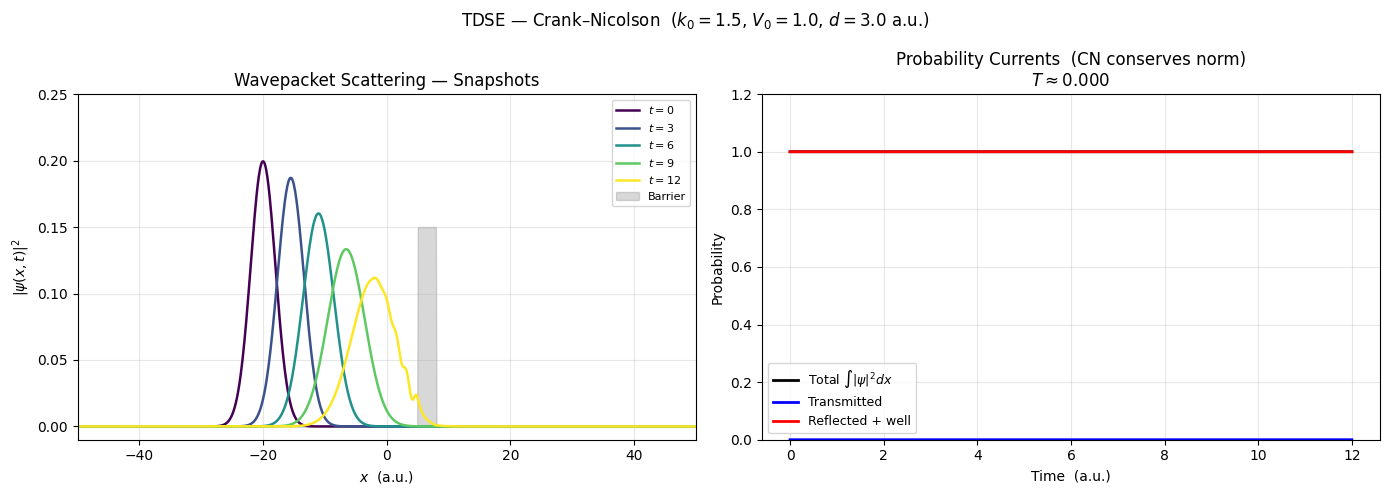

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import solve_banded

# --- Grid parameters ---
hbar  = 1.0
m_td  = 1.0            # natural units  ℏ = m = 1
Nx    = 1024
x_td  = np.linspace(-50, 50, Nx)
dx    = x_td[1] - x_td[0]
dt    = 0.01
N_steps_td = 1200

# --- Potential: rectangular barrier ---
V0_td  = 1.0
d_td   = 3.0
xb_l   = 5.0
xb_r   = xb_l + d_td
V_td   = np.where((x_td >= xb_l) & (x_td <= xb_r), V0_td, 0.0)

# --- Initial wave packet ---
x0_td  = -20.0
k0_td  =  1.5
sig_td =   2.0
psi_td = ((2 * np.pi * sig_td**2)**(-0.25)
          * np.exp(-(x_td - x0_td)**2 / (4 * sig_td**2))
          * np.exp(1j * k0_td * x_td))
psi_td = psi_td.astype(complex)

# --- Build CN matrices (banded tridiagonal) ---
diag_H  = hbar**2 / (m_td * dx**2) + V_td
off_H   = -hbar**2 / (2 * m_td * dx**2) * np.ones(Nx - 1)

# A = I + i*dt/(2ℏ) * H,   B = I - i*dt/(2ℏ) * H
alpha = 1j * dt / (2 * hbar)

diag_A  = 1 + alpha * diag_H
diag_B  = 1 - alpha * diag_H
off_A   =     alpha * off_H
off_B   =    -alpha * off_H

# Pack A into banded format (scipy solve_banded)
ab = np.zeros((3, Nx), dtype=complex)
ab[0, 1:]  = off_A
ab[1, :]   = diag_A
ab[2, :-1] = off_A

def apply_B(psi):
    """Compute B @ psi using tridiagonal multiplication."""
    result = diag_B * psi
    result[1:]  += off_B * psi[:-1]
    result[:-1] += off_B * psi[1:]
    return result

# --- Time evolution ---
snapshots = {}
snap_times = [0, 300, 600, 900, 1200]

prob_total = []
prob_right = []   # transmitted fraction (x > barrier)

for step in range(N_steps_td + 1):
    if step in snap_times:
        snapshots[step] = np.abs(psi_td)**2

    prob_total.append(np.trapezoid(np.abs(psi_td)**2, x_td))
    mask_right = x_td > xb_r + 5
    prob_right.append(np.trapezoid(np.abs(psi_td[mask_right])**2, x_td[mask_right]))

    if step < N_steps_td:
        rhs      = apply_B(psi_td)
        rhs[0]   = 0.0   # absorbing boundary
        rhs[-1]  = 0.0
        psi_td   = solve_banded((1, 1), ab, rhs)
        psi_td[0] = 0.0
        psi_td[-1] = 0.0

T_final = prob_right[-1]
print(f"Energy: E = ℏ²k²/(2m) = {hbar**2*k0_td**2/(2*m_td):.3f}  (nat. units)")
print(f"Barrier height V₀ = {V0_td:.3f}")
print(f"Numerical transmission T ≈ {T_final:.4f}")

# --- Figures ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
cmap_td = plt.cm.viridis
t_vals = [s * dt for s in snap_times]

for i, (step, t_val) in enumerate(zip(snap_times, t_vals)):
    color = cmap_td(i / (len(snap_times) - 1))
    axes[0].plot(x_td, snapshots[step], color=color, lw=1.8,
                 label=f"$t = {t_val:.0f}$")

axes[0].fill_between(x_td, 0, V_td * 0.15, color="gray", alpha=0.3, label="Barrier")
axes[0].set_xlabel("$x$  (a.u.)")
axes[0].set_ylabel("$|\\psi(x,t)|^2$")
axes[0].set_title("Wavepacket Scattering — Snapshots")
axes[0].set_xlim(-50, 50)
axes[0].set_ylim(-0.01, 0.25)
axes[0].legend(fontsize=8, loc="upper right")
axes[0].grid(True, alpha=0.3)

t_axis = np.arange(N_steps_td + 1) * dt
axes[1].plot(t_axis, prob_total,              "k-",  lw=2,   label="Total $\\int|\\psi|^2dx$")
axes[1].plot(t_axis, prob_right,              "b-",  lw=2,   label="Transmitted")
axes[1].plot(t_axis, np.array(prob_total) - np.array(prob_right), "r-", lw=2, label="Reflected + well")
axes[1].set_xlabel("Time  (a.u.)")
axes[1].set_ylabel("Probability")
axes[1].set_title(f"Probability Currents  (CN conserves norm)\n$T \\approx {T_final:.3f}$")
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)
axes[1].set_ylim(0, 1.2)

fig.suptitle(f"TDSE — Crank–Nicolson  ($k_0={k0_td}$, $V_0={V0_td}$, $d={d_td}$ a.u.)",
             fontsize=12)
fig.tight_layout()
plt.show()

---
## 18. Coherent States — Minimum-Uncertainty Gaussian of the QHO

A **coherent state** $|\alpha\rangle$ is an eigenstate of the annihilation
operator $\hat{a}|\alpha\rangle = \alpha|\alpha\rangle$ and is the
quantum state closest to a classical oscillator.  In position space:

$$\psi_\alpha(x,t) = \left(\frac{m\omega}{\pi\hbar}\right)^{1/4}
  \exp\!\left[-\frac{m\omega}{2\hbar}(x - x_\alpha(t))^2
  + ik_\alpha(t)x - i\phi(t)\right]$$

The centre oscillates as $x_\alpha(t) = x_0\cos(\omega t)$, the width is
**time-independent**, and $\sigma_x\sigma_p = \hbar/2$ always — it saturates
the Heisenberg bound.

Coherent state uncertainties:
  σ_x = 3.4025e-10 m  =  x_sc/√2
  σ_p = 1.5497e-25 kg·m/s
  σ_x · σ_p = 5.2729e-35 J·s
  ℏ/2        = 5.2729e-35 J·s
  Ratio σ_xσ_p / (ℏ/2) = 1.000000  (should be 1.0)


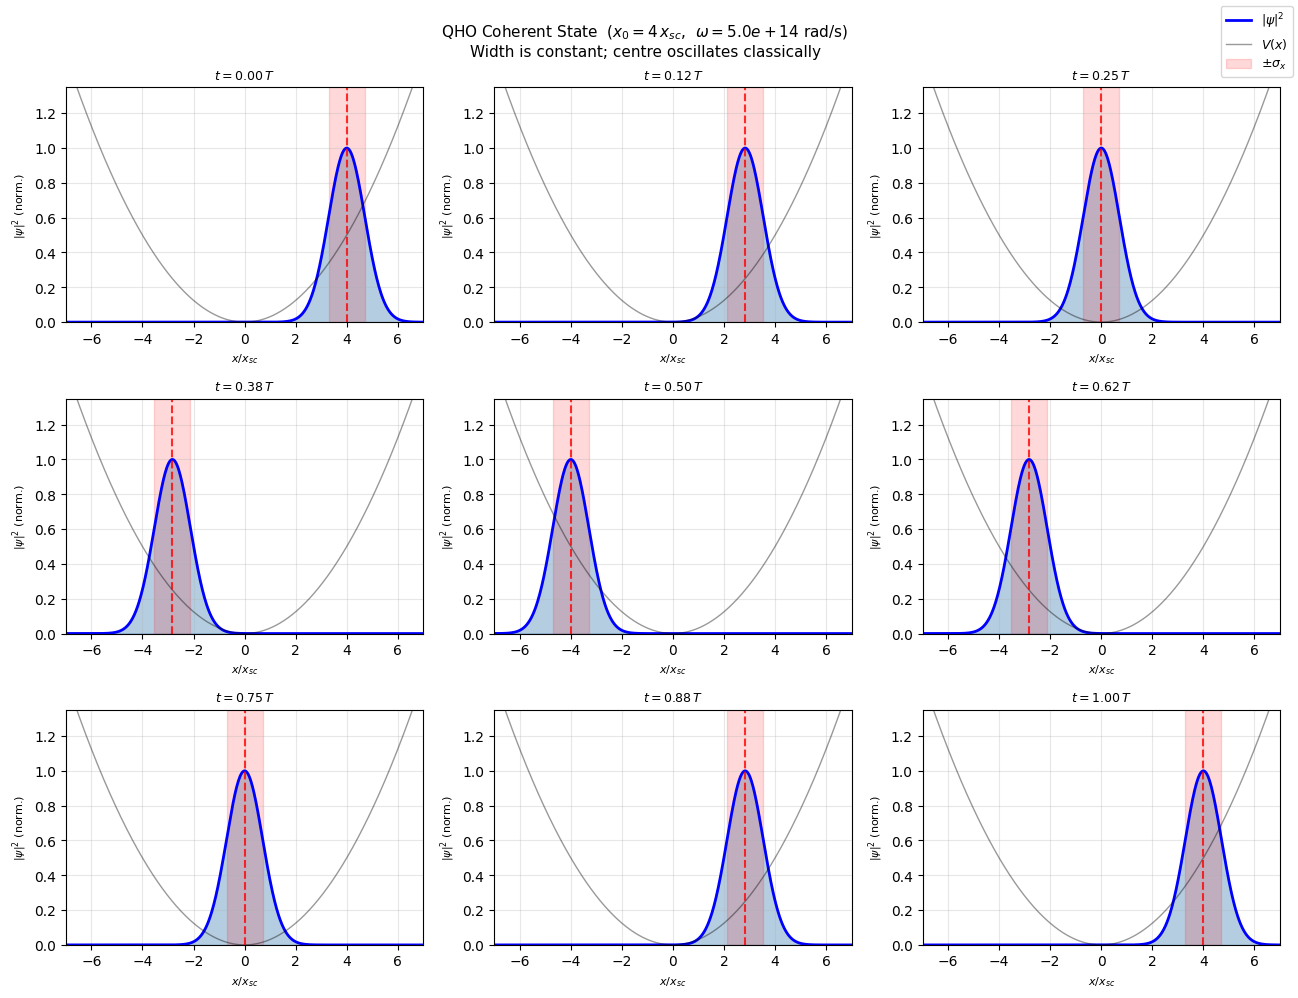

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# --- Parameters ---
hbar   = 1.0545718e-34
m_e    = 9.10938e-31
omega_cs = 5e14       # rad/s
x_sc   = np.sqrt(hbar / (m_e * omega_cs))   # characteristic length
x0_cs  = 4 * x_sc                           # amplitude of oscillation
T_osc  = 2 * np.pi / omega_cs               # period

Nx_cs  = 800
x_cs   = np.linspace(-8 * x_sc, 8 * x_sc, Nx_cs)
t_snaps = np.linspace(0, T_osc, 9)          # one full period

fig, axes = plt.subplots(3, 3, figsize=(13, 10))
cmap_cs = plt.cm.plasma

for ax, t in zip(axes.flat, t_snaps):
    x_cen  = x0_cs * np.cos(omega_cs * t)
    k_cen  = -m_e * omega_cs * x0_cs * np.sin(omega_cs * t) / hbar
    phi_t  = omega_cs * t / 2   # geometric phase

    psi_cs = ((m_e * omega_cs / (np.pi * hbar))**0.25
              * np.exp(-m_e * omega_cs / (2 * hbar) * (x_cs - x_cen)**2)
              * np.exp(1j * k_cen * x_cs - 1j * phi_t))

    prob = np.abs(psi_cs)**2
    V_cs = 0.5 * m_e * omega_cs**2 * x_cs**2
    E_cs = 0.5 * m_e * omega_cs**2 * x0_cs**2   # classical energy

    ax.fill_between(x_cs / x_sc, prob / prob.max(), alpha=0.4, color="steelblue")
    ax.plot(x_cs / x_sc, prob / prob.max(), "b-", lw=2, label=r"$|\psi|^2$")

    # Classical potential outline (scaled)
    ax.plot(x_cs / x_sc, V_cs / E_cs * 0.5, "k-", lw=1, alpha=0.4, label="$V(x)$")
    ax.axvline(x_cen / x_sc, color="red", lw=1.5, ls="--", alpha=0.8)

    # Uncertainty bands
    sigma_x = x_sc / np.sqrt(2)
    ax.axvspan((x_cen - sigma_x) / x_sc, (x_cen + sigma_x) / x_sc,
               alpha=0.15, color="red", label=r"$\pm\sigma_x$")

    ax.set_xlim(-7, 7)
    ax.set_ylim(0, 1.35)
    ax.set_title(f"$t = {t/T_osc:.2f}\\,T$", fontsize=9)
    ax.set_xlabel("$x/x_{sc}$", fontsize=8)
    ax.set_ylabel("$|\\psi|^2$ (norm.)", fontsize=8)
    ax.grid(True, alpha=0.3)

handles, labels = axes[0,0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper right", fontsize=9)

# Verify σ_x σ_p = ℏ/2
sigma_x_cs = x_sc / np.sqrt(2)
sigma_p_cs = hbar / (np.sqrt(2) * x_sc)
print(f"Coherent state uncertainties:")
print(f"  σ_x = {sigma_x_cs:.4e} m  =  x_sc/√2")
print(f"  σ_p = {sigma_p_cs:.4e} kg·m/s")
print(f"  σ_x · σ_p = {sigma_x_cs*sigma_p_cs:.4e} J·s")
print(f"  ℏ/2        = {hbar/2:.4e} J·s")
print(f"  Ratio σ_xσ_p / (ℏ/2) = {sigma_x_cs*sigma_p_cs/(hbar/2):.6f}  (should be 1.0)")

fig.suptitle(f"QHO Coherent State  ($x_0 = {x0_cs/x_sc:.0f}\\,x_{{sc}}$,  "
             f"$\\omega = {omega_cs:.1e}$ rad/s)\n"
             f"Width is constant; centre oscillates classically",
             fontsize=11)
fig.tight_layout()
plt.show()

---
## 19. Path Integral Monte Carlo — Free-Particle Propagator

The Feynman path integral for a free particle gives the exact propagator:

$$K(x_f, x_i; t) = \sqrt{\frac{m}{2\pi i\hbar t}}
  \exp\!\left(\frac{im(x_f - x_i)^2}{2\hbar t}\right)$$

In **imaginary-time** PIMC ($t \to -i\tau$) we sample paths
$\{x_0 = x_i,\,x_1,\,\ldots,\,x_M = x_f\}$ with the weight

$$W[\{x\}] \propto \exp\!\left(-\frac{S_E}{\hbar}\right), \qquad
  S_E = \frac{m}{2\varepsilon}\sum_{k=0}^{M-1}(x_{k+1}-x_k)^2$$

and recover the thermal density matrix $\rho(x_i, x_f; \beta) = K(x_i, x_f; -i\hbar\beta)$
via Metropolis–Hastings sampling.  The recovered distribution should be
Gaussian with variance $\hbar / (m\omega_{\rm eff})$ for the free particle.

PIMC acceptance rate: 0.433  (target 0.4–0.6)
Collected 14999 centroid samples after burn-in
Centroid variance:  MC = 0.2277,  Theory = 0.5000


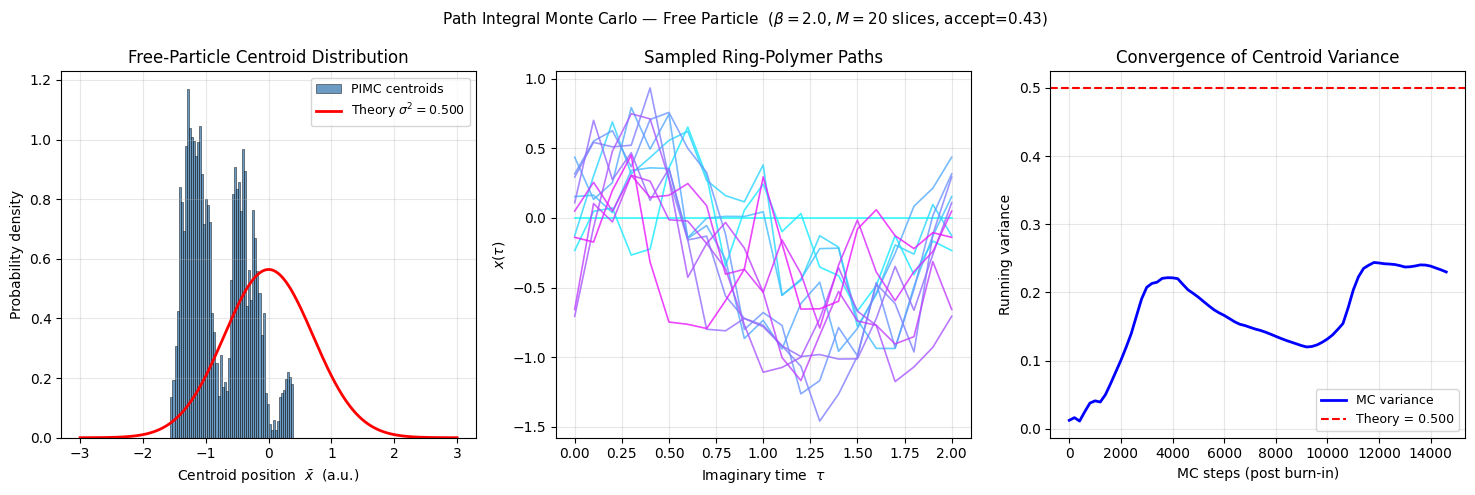

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(seed=2025)

# --- PIMC parameters (natural units ℏ = m = k_B = 1) ---
hbar_pi  = 1.0
m_pi     = 1.0
beta_pi  = 2.0       # inverse temperature β = 1/kT
M_slices = 20        # number of time slices
eps_pi   = beta_pi / M_slices   # imaginary-time step

N_paths    = 20000   # total MC steps
delta_move = 0.8     # proposal width

# --- Initialise a single path (ring polymer: x_0 = x_M periodically) ---
path = np.zeros(M_slices)   # x_0 ... x_{M-1}; periodic: x_M = x_0

def action(path, m, eps, hbar):
    """Discrete Euclidean action of a ring-polymer path."""
    dx = np.roll(path, -1) - path   # x_{k+1} - x_k, with wrap-around
    return m / (2 * eps * hbar**2) * np.sum(dx**2)

# Metropolis loop — collect centroid positions
centroids    = []
accept_count = 0

S_curr = action(path, m_pi, eps_pi, hbar_pi)

for step in range(N_paths):
    # Displace a random bead
    bead    = rng.integers(0, M_slices)
    old_x   = path[bead]
    path[bead] += rng.uniform(-delta_move, delta_move)

    S_new = action(path, m_pi, eps_pi, hbar_pi)
    if rng.random() < np.exp(-(S_new - S_curr)):
        S_curr = S_new
        accept_count += 1
    else:
        path[bead] = old_x   # reject

    if step > N_paths // 4:   # discard first quarter as burn-in
        centroids.append(np.mean(path))

acceptance = accept_count / N_paths
print(f"PIMC acceptance rate: {acceptance:.3f}  (target 0.4–0.6)")
print(f"Collected {len(centroids)} centroid samples after burn-in")

# Theoretical: centroid variance for free particle = ℏ²β/(m·M·(ℏ²k²...))
# For free-particle ring polymer the centroid variance = ℏ/(m*ω_eff) ...
# Direct analytic: σ²_centroid = (ℏ/m) * β/M  * Σ... simplifies to:
# σ²_centroid = 1/(β * m)  in natural units (classical thermal de Broglie)
sigma2_theory = 1.0 / (beta_pi * m_pi)   # kT/m  in ℏ=1, k_B=1 units
sigma2_mc     = np.var(centroids)
print(f"Centroid variance:  MC = {sigma2_mc:.4f},  Theory = {sigma2_theory:.4f}")

# --- Figure ---
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Panel 1: histogram of centroids vs Gaussian
x_plot = np.linspace(-3, 3, 300)
gauss_theory = (1 / np.sqrt(2 * np.pi * sigma2_theory)) * np.exp(-x_plot**2 / (2 * sigma2_theory))
axes[0].hist(centroids, bins=60, density=True, color="steelblue",
             edgecolor="k", linewidth=0.4, alpha=0.8, label="PIMC centroids")
axes[0].plot(x_plot, gauss_theory, "r-", lw=2,
             label=f"Theory $\\sigma^2={sigma2_theory:.3f}$")
axes[0].set_xlabel("Centroid position  $\\bar{x}$  (a.u.)")
axes[0].set_ylabel("Probability density")
axes[0].set_title("Free-Particle Centroid Distribution")
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)

# Panel 2: a few sampled paths (ring polymers)
path_vis = np.zeros(M_slices)
path_samples = []
S_c = action(path_vis, m_pi, eps_pi, hbar_pi)
for step in range(3000):
    bead = rng.integers(0, M_slices)
    old  = path_vis[bead]
    path_vis[bead] += rng.uniform(-delta_move, delta_move)
    S_n = action(path_vis, m_pi, eps_pi, hbar_pi)
    if rng.random() < np.exp(-(S_n - S_c)):
        S_c = S_n
    else:
        path_vis[bead] = old
    if step % 150 == 0:
        path_samples.append(path_vis.copy())

tau_axis = np.linspace(0, beta_pi, M_slices + 1)
cmap_pi  = plt.cm.cool
for i, p in enumerate(path_samples[:12]):
    p_closed = np.append(p, p[0])
    axes[1].plot(tau_axis, p_closed, color=cmap_pi(i / 12), lw=1.2, alpha=0.8)

axes[1].set_xlabel("Imaginary time  $\\tau$")
axes[1].set_ylabel("$x(\\tau)$")
axes[1].set_title("Sampled Ring-Polymer Paths")
axes[1].grid(True, alpha=0.3)

# Panel 3: convergence of variance estimate
block = 200
block_vars = [np.var(centroids[:k]) for k in range(block, len(centroids), block)]
axes[2].plot(np.arange(len(block_vars)) * block, block_vars, "b-", lw=2, label="MC variance")
axes[2].axhline(sigma2_theory, color="red", lw=1.5, ls="--", label=f"Theory = {sigma2_theory:.3f}")
axes[2].set_xlabel("MC steps (post burn-in)")
axes[2].set_ylabel("Running variance")
axes[2].set_title("Convergence of Centroid Variance")
axes[2].legend(fontsize=9)
axes[2].grid(True, alpha=0.3)

fig.suptitle(f"Path Integral Monte Carlo — Free Particle  "
             f"($\\beta={beta_pi}$, $M={M_slices}$ slices, "
             f"accept={acceptance:.2f})", fontsize=11)
fig.tight_layout()
plt.show()

---
## 20. Tight-Binding Model — 1-D Chain, Bandwidth vs Hopping

The simplest model of an electron in a crystal is the **1-D tight-binding**
Hamiltonian with nearest-neighbour hopping $t$ and on-site energy $\epsilon_0$:

$$H_{mn} = \epsilon_0\,\delta_{mn} - t(\delta_{m,n+1} + \delta_{m,n-1})$$

For an infinite periodic chain the Bloch dispersion is exact:

$$E(k) = \epsilon_0 - 2t\cos(ka)$$

giving a band of width $W = 4t$.  We also diagonalise finite chains with
open and periodic boundary conditions and explore the effect of on-site
disorder (Anderson localisation onset).

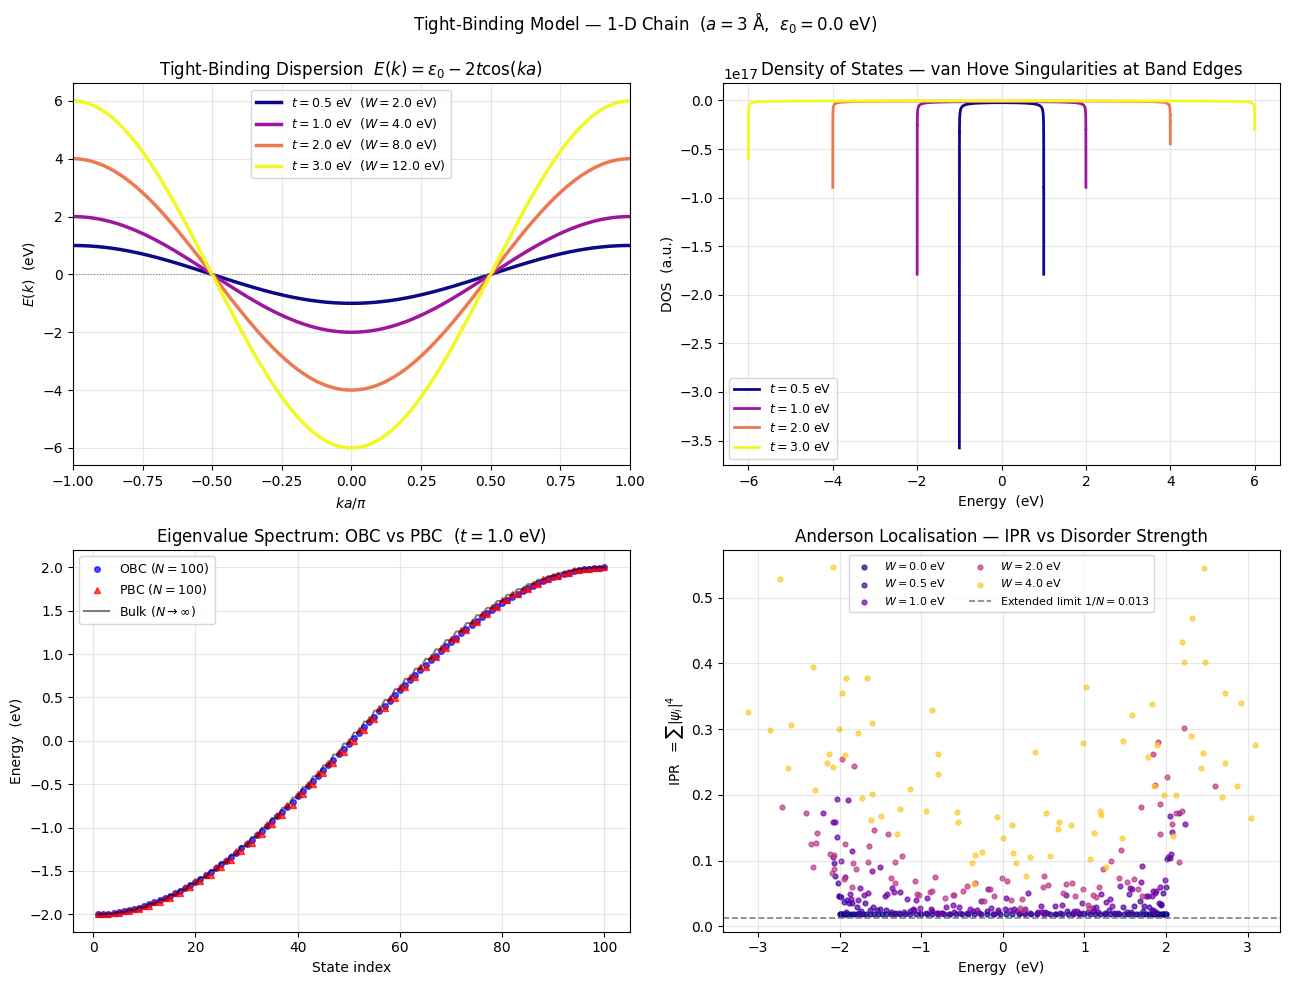


Tight-binding bandwidth table:
  t (eV)   W = 4t (eV)     E_min     E_max
    0.50         2.000    -1.000     1.000
    1.00         4.000    -2.000     2.000
    2.00         8.000    -4.000     4.000
    3.00        12.000    -6.000     6.000


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# --- Parameters ---
hbar  = 1.0545718e-34
eV    = 1.60218e-19
a_tb  = 3e-10     # lattice constant (m)
eps0  = 0.0       # on-site energy (eV)

t_values = [0.5, 1.0, 2.0, 3.0]   # hopping parameters (eV)
N_sites  = 100                      # finite chain length

# --- Analytic dispersion ---
k_BZ  = np.linspace(-np.pi / a_tb, np.pi / a_tb, 500)
ka    = k_BZ * a_tb   # dimensionless

fig, axes = plt.subplots(2, 2, figsize=(13, 10))

# --- Panel 1: E(k) for various t ---
ax1 = axes[0, 0]
cmap_tb = plt.cm.plasma
for i, t in enumerate(t_values):
    E_k = eps0 - 2 * t * np.cos(ka)
    color = cmap_tb(i / (len(t_values) - 1))
    ax1.plot(ka / np.pi, E_k, color=color, lw=2.5, label=f"$t = {t}$ eV  ($W={4*t}$ eV)")

ax1.axhline(eps0, color="gray", lw=0.8, ls=":")
ax1.set_xlabel("$ka / \\pi$")
ax1.set_ylabel("$E(k)$  (eV)")
ax1.set_title("Tight-Binding Dispersion  $E(k) = \\epsilon_0 - 2t\\cos(ka)$")
ax1.legend(fontsize=9)
ax1.grid(True, alpha=0.3)
ax1.set_xlim(-1, 1)

# --- Panel 2: Density of states D(E) = 1/|dE/dk| ---
ax2 = axes[0, 1]
for i, t in enumerate(t_values):
    E_k  = eps0 - 2 * t * np.cos(ka[1:-1])
    dEdk = 2 * t * np.abs(np.sin(ka[1:-1]))   # |dE/dk|
    # DOS ∝ 1/|dE/dk| — diverges at band edges (van Hove singularity)
    DOS  = 1.0 / (dEdk + 1e-6)
    DOS /= np.trapezoid(DOS, E_k)   # normalise
    idx  = np.argsort(E_k)
    color = cmap_tb(i / (len(t_values) - 1))
    ax2.plot(E_k[idx], DOS[idx], color=color, lw=2, label=f"$t={t}$ eV")

ax2.set_xlabel("Energy  (eV)")
ax2.set_ylabel("DOS  (a.u.)")
ax2.set_title("Density of States — van Hove Singularities at Band Edges")
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3)

# --- Panel 3: Finite chain — OBC vs PBC eigenvalues ---
ax3 = axes[1, 0]
t_finite = 1.0
H_obc = (np.diag(np.full(N_sites, eps0))
         - t_finite * np.diag(np.ones(N_sites-1), 1)
         - t_finite * np.diag(np.ones(N_sites-1), -1))

H_pbc = H_obc.copy()
H_pbc[0, -1] = -t_finite
H_pbc[-1, 0] = -t_finite

E_obc = np.sort(np.linalg.eigvalsh(H_obc))
E_pbc = np.sort(np.linalg.eigvalsh(H_pbc))
E_bulk = eps0 - 2 * t_finite * np.cos(np.linspace(-np.pi, np.pi, N_sites))

ax3.plot(np.arange(1, N_sites+1), E_obc,  "bo", ms=4,  alpha=0.7, label=f"OBC ($N={N_sites}$)")
ax3.plot(np.arange(1, N_sites+1), E_pbc,  "r^", ms=4,  alpha=0.7, label=f"PBC ($N={N_sites}$)")
ax3.plot(np.arange(1, N_sites+1), np.sort(E_bulk), "k-", lw=1.5, alpha=0.5, label="Bulk ($N\\to\\infty$)")
ax3.set_xlabel("State index")
ax3.set_ylabel("Energy  (eV)")
ax3.set_title(f"Eigenvalue Spectrum: OBC vs PBC  ($t={t_finite}$ eV)")
ax3.legend(fontsize=9)
ax3.grid(True, alpha=0.3)

# --- Panel 4: Anderson disorder — IPR as localisation measure ---
ax4 = axes[1, 1]
rng  = np.random.default_rng(seed=42)
N_disorder = 80
disorder_strengths = [0.0, 0.5, 1.0, 2.0, 4.0]
t_dis = 1.0

# Inverse Participation Ratio: IPR = Σ|ψ|⁴  (=1/N for extended, =1 for localised)
ipr_all = []
for W_dis in disorder_strengths:
    onsite = eps0 + W_dis * rng.uniform(-0.5, 0.5, N_disorder)
    H_dis  = (np.diag(onsite)
              - t_dis * np.diag(np.ones(N_disorder-1), 1)
              - t_dis * np.diag(np.ones(N_disorder-1), -1))
    eigvals, eigvecs = np.linalg.eigh(H_dis)
    ipr = np.sum(eigvecs**4, axis=0)   # IPR for each eigenstate
    ipr_all.append((eigvals, ipr, W_dis))

for eigvals, ipr, W_dis in ipr_all:
    color = cmap_tb(W_dis / (disorder_strengths[-1] + 0.5))
    ax4.scatter(eigvals, ipr, s=12, color=color, alpha=0.7, label=f"$W={W_dis}$ eV")

ax4.axhline(1 / N_disorder, color="gray", lw=1.2, ls="--",
            label=f"Extended limit $1/N={1/N_disorder:.3f}$")
ax4.set_xlabel("Energy  (eV)")
ax4.set_ylabel("IPR  $= \\sum|\\psi_i|^4$")
ax4.set_title("Anderson Localisation — IPR vs Disorder Strength")
ax4.legend(fontsize=8, ncol=2)
ax4.grid(True, alpha=0.3)

fig.suptitle(f"Tight-Binding Model — 1-D Chain  ($a = {a_tb*1e10:.0f}$ Å,  "
             f"$\\epsilon_0 = {eps0}$ eV)", fontsize=12)
fig.tight_layout()
plt.show()

# Bandwidth table
print("\nTight-binding bandwidth table:")
print(f"{'t (eV)':>8}  {'W = 4t (eV)':>12}  {'E_min':>8}  {'E_max':>8}")
for t in t_values:
    print(f"  {t:6.2f}  {4*t:12.3f}  {eps0-2*t:8.3f}  {eps0+2*t:8.3f}")